<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Imports" data-toc-modified-id="Imports-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Imports</a></span></li><li><span><a href="#Download-Data" data-toc-modified-id="Download-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Download Data</a></span></li><li><span><a href="#Split-DataFrame-For-Train-Validation-and-Test" data-toc-modified-id="Split-DataFrame-For-Train-Validation-and-Test-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Split DataFrame For Train Validation and Test</a></span></li><li><span><a href="#Build-a-Benchmark-Model" data-toc-modified-id="Build-a-Benchmark-Model-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Build a Benchmark Model</a></span><ul class="toc-item"><li><span><a href="#make-most-basic-features" data-toc-modified-id="make-most-basic-features-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>make most basic features</a></span></li><li><span><a href="#make-benchmark-model" data-toc-modified-id="make-benchmark-model-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>make benchmark model</a></span></li><li><span><a href="#walkforward-function" data-toc-modified-id="walkforward-function-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>walkforward function</a></span></li><li><span><a href="#look-at-results" data-toc-modified-id="look-at-results-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>look at results</a></span></li></ul></li><li><span><a href="#Build-a-More-Advanced-Model" data-toc-modified-id="Build-a-More-Advanced-Model-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Build a More Advanced Model</a></span><ul class="toc-item"><li><span><a href="#make-xy-with-new-features" data-toc-modified-id="make-xy-with-new-features-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>make xy with new features</a></span></li><li><span><a href="#run-walkforward-test" data-toc-modified-id="run-walkforward-test-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>run walkforward test</a></span></li><li><span><a href="#evaluate-results" data-toc-modified-id="evaluate-results-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>evaluate results</a></span></li></ul></li><li><span><a href="#Build-a-Model-With-Market-Marketstructure-features" data-toc-modified-id="Build-a-Model-With-Market-Marketstructure-features-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Build a Model With Market Marketstructure features</a></span><ul class="toc-item"><li><span><a href="#add-features" data-toc-modified-id="add-features-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>add features</a></span></li><li><span><a href="#run-walkforward-test" data-toc-modified-id="run-walkforward-test-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>run walkforward test</a></span></li><li><span><a href="#evaluate-results" data-toc-modified-id="evaluate-results-6.3"><span class="toc-item-num">6.3&nbsp;&nbsp;</span>evaluate results</a></span></li></ul></li><li><span><a href="#Feature-Select-for-Technical-Analysis-Features" data-toc-modified-id="Feature-Select-for-Technical-Analysis-Features-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Feature Select for Technical Analysis Features</a></span><ul class="toc-item"><li><span><a href="#use-selected-features-only" data-toc-modified-id="use-selected-features-only-7.1"><span class="toc-item-num">7.1&nbsp;&nbsp;</span>use selected features only</a></span></li><li><span><a href="#run-walkforward-test" data-toc-modified-id="run-walkforward-test-7.2"><span class="toc-item-num">7.2&nbsp;&nbsp;</span>run walkforward test</a></span></li><li><span><a href="#evaluate-results" data-toc-modified-id="evaluate-results-7.3"><span class="toc-item-num">7.3&nbsp;&nbsp;</span>evaluate results</a></span></li><li><span><a href="#let's-attempt-with-tentative-and-selected" data-toc-modified-id="let's-attempt-with-tentative-and-selected-7.4"><span class="toc-item-num">7.4&nbsp;&nbsp;</span>let's attempt with tentative and selected</a></span></li><li><span><a href="#run-walkforward" data-toc-modified-id="run-walkforward-7.5"><span class="toc-item-num">7.5&nbsp;&nbsp;</span>run walkforward</a></span></li><li><span><a href="#Evaluate-Results" data-toc-modified-id="Evaluate-Results-7.6"><span class="toc-item-num">7.6&nbsp;&nbsp;</span>Evaluate Results</a></span></li></ul></li><li><span><a href="#Test-model-on-Validation-Set" data-toc-modified-id="Test-model-on-Validation-Set-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Test model on Validation Set</a></span><ul class="toc-item"><li><span><a href="#run-walkforward" data-toc-modified-id="run-walkforward-8.1"><span class="toc-item-num">8.1&nbsp;&nbsp;</span>run walkforward</a></span></li><li><span><a href="#evaluate-results" data-toc-modified-id="evaluate-results-8.2"><span class="toc-item-num">8.2&nbsp;&nbsp;</span>evaluate results</a></span></li></ul></li></ul></div>

# Imports

In [5]:
%load_ext watermark
%watermark

%load_ext autoreload
%autoreload 2

#%load_ext nb_black


from pathlib import Path
# import visual tools
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns_params = {
    "xtick.major.size": 2,
    "ytick.major.size": 2,
    "font.size": 12,
    "font.weight": "medium",
    "figure.figsize": (10, 7),
}
sns.set_theme(
    context="notebook",
    style="darkgrid",
    # palette=sns.color_palette("magma"),
    rc=sns_params,
)
savefig_kwds = dict(dpi=90, bbox_inches="tight", frameon=True, format="png")

# import util libs
from timeutils import Stopwatch
from tqdm import tqdm
import warnings

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef
from statsmodels.tsa.stattools import acf
from timeseries_features import (
    hurst,
    permutation_entropy,
    kyles_lambda,
    bekker_parkinson_vol,
    amihuds_lambda,
    hasbroucks_lambda,
    corwin_schultz_hl,
    roll_measure,
)
import yfinance as yf
import quantstats as qs
from ta import add_all_ta_features
from BorutaShap import BorutaShap

warnings.filterwarnings("ignore")
import watermark.watermark as watermark
# ---------------------------------------------------
# THESE ARE VARIABLES FOR EASILY ACCESSING DIFFERENT
# DIRECTORIES FOR ACCESSING AND SAVING DATA AND IMAGES
# IF NECESSARY. CHANGE THEM TO MATCH YOUR DIRECTORY
# STRUCTURE.
# ---------------------------------------------------
from blk_utils import cprint, get_relative_project_dir

REPO_NAME = "blackarbs_algo_strategy_dev"  # CHANGE TO MATCH YOUR REPO NAME
print("\n", REPO_NAME)
project_dir = get_relative_project_dir(REPO_NAME)
data_dir = project_dir / "data"
external = data_dir / "external"
processed = data_dir / "processed"


print()
%watermark -v --iversions

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: 2023-06-09T20:18:35.694581-03:00

Python implementation: CPython
Python version       : 3.9.16
IPython version      : 8.1.1

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 122 Stepping 1, GenuineIntel
CPU cores   : 4
Architecture: 64bit

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

 blackarbs_algo_strategy_dev

Python implementation: CPython
Python version       : 3.9.16
IPython version      : 8.1.1

quantstats: 0.0.59
seaborn   : 0.12.0
yfinance  : 0.1.75
matplotlib: 3.6.0
pandas    : 1.4.1
numpy     : 1.23.0



# Download Data

In [6]:
def process_data(indf, resample_freq="1H"):
    out_df = indf.copy()
    # resample
    out_df = out_df.resample(resample_freq).agg(
        {"open": "first", "high": max, "low": min, "close": "last", "volume": sum}
    )
    out_df.dropna(inplace=True)
    return out_df

In [7]:
SYMBOL = "XLF" # SPDR Financial ETF

raw_df = yf.Ticker(SYMBOL).history(period="max").rename(columns=str.lower)
cprint(raw_df)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                                open       high        low      close  volume  \
Date                                                                            
1998-12-22 00:00:00-05:00  11.787855  11.787855  11.662202  11.717175   55887   
1998-12-23 00:00:00-05:00  11.670059  11.889953  11.670059  11.889953   78784   
1998-12-24 00:00:00-05:00  11.889951  11.968484  11.850684  11.968484   43824   
1998-12-28 00:00:00-05:00  11.960631  11.960631  11.780005  11.811419   51948   
1998-12-29 00:00:00-05:00  11.827125  11.937073  11.685765  11.937073  100819   

                           dividends  stock splits  
Date                                                
1998-12-22 00:00:00-05:00        0.0           0.0  
1998-12-23 00:00:00-05:00        0.0           0.0  
1998-12-24 00:00:00-0

In [8]:
df = process_data(raw_df, resample_freq="1D")
df

,open,high,low,close,volume
Date,,,,,
1998-12-22 00:00:00-05:00,11.787855,11.787855,11.662202,11.717175,55887
1998-12-23 00:00:00-05:00,11.670059,11.889953,11.670059,11.889953,78784
1998-12-24 00:00:00-05:00,11.889951,11.968484,11.850684,11.968484,43824
1998-12-28 00:00:00-05:00,11.960631,11.960631,11.780005,11.811419,51948
1998-12-29 00:00:00-05:00,11.827125,11.937073,11.685765,11.937073,100819
...,...,...,...,...,...
2023-06-05 00:00:00-04:00,32.840000,32.840000,32.480000,32.630001,53591100
2023-06-06 00:00:00-04:00,32.599998,33.090000,32.580002,33.040001,46236100
2023-06-07 00:00:00-04:00,33.070000,33.240002,32.869999,33.169998,48467100


# Split DataFrame For Train Validation and Test

- Training Set: you want to develop all your features and test your favorite models and model combinations
- Validation Set: you want to optimize your best model's parameters
    - hyperparameter tuning - your model has parameters (Xgboost, randomforest etc.)
    - if scoring metric degrades between training set and validation set **before** optimization of the model parameters, start over, because your features are **not** predictive, and you have already overfit in the training phase.
- Test Set: use one time, to validate your entire model out of sample

In [9]:
df_train = df.loc[:"2012"]
cprint(df_train)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                                open       high        low      close  volume
Date                                                                         
1998-12-22 00:00:00-05:00  11.787855  11.787855  11.662202  11.717175   55887
1998-12-23 00:00:00-05:00  11.670059  11.889953  11.670059  11.889953   78784
1998-12-24 00:00:00-05:00  11.889951  11.968484  11.850684  11.968484   43824
1998-12-28 00:00:00-05:00  11.960631  11.960631  11.780005  11.811419   51948
1998-12-29 00:00:00-05:00  11.827125  11.937073  11.685765  11.937073  100819
-------------------------
TAIL num rows: 5
                                open       high        low      close  \
Date                                                                    
2012-12-24 00:00:00-05:00  10.908223  10.968379  10.901540  10.941

In [10]:
df_validation = df.loc["2013":"2015"]
df_validation

,open,high,low,close,volume
Date,,,,,
2013-01-02 00:00:00-05:00,11.229051,11.282523,11.188946,11.275838,86126792
2013-01-03 00:00:00-05:00,11.275840,11.295892,11.215685,11.262472,59026942
2013-01-04 00:00:00-05:00,11.282525,11.416204,11.255790,11.396152,54822954
2013-01-07 00:00:00-05:00,11.376100,11.382784,11.302577,11.369416,44491664
2013-01-08 00:00:00-05:00,11.349366,11.356050,11.282527,11.335999,51457154
...,...,...,...,...,...
2015-12-24 00:00:00-05:00,16.941634,16.997965,16.864178,16.906427,13844688
2015-12-28 00:00:00-05:00,16.836011,16.899383,16.751513,16.892342,16747016
2015-12-29 00:00:00-05:00,17.033172,17.089502,16.976841,17.068378,38040239


In [11]:
df_test = df.loc["2016":]
cprint(df_test)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                                open       high        low      close  \
Date                                                                    
2016-01-04 00:00:00-05:00  16.434656  16.469863  16.265662  16.455780   
2016-01-05 00:00:00-05:00  16.483943  16.568439  16.371280  16.519150   
2016-01-06 00:00:00-05:00  16.279746  16.364242  16.181165  16.265663   
2016-01-07 00:00:00-05:00  15.927671  16.075541  15.744594  15.807966   
2016-01-08 00:00:00-05:00  15.948797  15.962879  15.526311  15.561520   

                             volume  
Date                                 
2016-01-04 00:00:00-05:00  93387476  
2016-01-05 00:00:00-05:00  52096536  
2016-01-06 00:00:00-05:00  77248574  
2016-01-07 00:00:00-05:00  92006910  
2016-01-08 00:00:00-05:00  83028242  
-----------------------

# Build a Benchmark Model

The first iteration will use an extremely basic feature set to function as a benchmark model, that predicts the sign of the forward return over N periods. classification model.

In [12]:
hdf_store_fp = "AGG_RESULTS_2.h5"
hdf_store = pd.HDFStore(hdf_store_fp, mode="a", complevel=3, complib="blosc:lz4")

# ROLLING WINDOW
WINDOW = 30
# PREDICTION HORIZON
HORIZON = 8

In [13]:
actual_returns = df["close"].pct_change()

# target
Y_TARGET_COL = f"fwd_{HORIZON}"

forward_returns = df["close"].pct_change(-HORIZON).dropna()
df_train[Y_TARGET_COL] = forward_returns.apply(np.sign)

print(df_train[Y_TARGET_COL].value_counts())

# remove zeros

df_train = df_train[df_train[Y_TARGET_COL] != 0.0]
print(df_train[Y_TARGET_COL].value_counts())

-1.0    1870
 1.0    1639
 0.0      19
Name: fwd_8, dtype: int64
-1.0    1870
 1.0    1639
Name: fwd_8, dtype: int64


## make most basic features

In [14]:
# features
def add_features(indf, window=30):
    out_df = indf.copy()
    # add momentum
    out_df["momo"] = (
        out_df["close"].rolling(window // 3).mean()
        - out_df["close"].rolling(window).mean()
    )
    # add volatility estimator
    out_df["vol"] = out_df["close"].rolling(window).std()
    return out_df.ffill().dropna()


drop_cols = ["open", "high", "low", "close"]
Xdf = add_features(df_train, window=WINDOW).drop(drop_cols, axis=1)
cprint(Xdf)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                           volume  fwd_8      momo       vol
Date                                                        
1999-02-04 00:00:00-05:00   48625   -1.0 -0.168324  0.254007
1999-02-05 00:00:00-05:00  103035   -1.0 -0.180366  0.268234
1999-02-08 00:00:00-05:00  137749   -1.0 -0.198168  0.283768
1999-02-09 00:00:00-05:00  264050   -1.0 -0.224607  0.306098
1999-02-10 00:00:00-05:00   31883   -1.0 -0.235078  0.320935
-------------------------
TAIL num rows: 5
                             volume  fwd_8      momo       vol
Date                                                          
2012-12-24 00:00:00-05:00  29586100   -1.0  0.300470  0.268829
2012-12-26 00:00:00-05:00  36545928   -1.0  0.306342  0.274447
2012-12-27 00:00:00-05:00  54714996   -1.0  0.302454  0.273839
2012-12-28 00:00

In [15]:
# train data
def create_Xy(indf, feature_cols, y_target_col):
    return indf[feature_cols], indf[y_target_col].to_frame()


FEAT_COLS = [x for x in Xdf.columns if "fwd" not in x]
X, y = create_Xy(Xdf, FEAT_COLS, Y_TARGET_COL)
cprint(X)
cprint(y)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                           volume      momo       vol
Date                                                 
1999-02-04 00:00:00-05:00   48625 -0.168324  0.254007
1999-02-05 00:00:00-05:00  103035 -0.180366  0.268234
1999-02-08 00:00:00-05:00  137749 -0.198168  0.283768
1999-02-09 00:00:00-05:00  264050 -0.224607  0.306098
1999-02-10 00:00:00-05:00   31883 -0.235078  0.320935
-------------------------
TAIL num rows: 5
                             volume      momo       vol
Date                                                   
2012-12-24 00:00:00-05:00  29586100  0.300470  0.268829
2012-12-26 00:00:00-05:00  36545928  0.306342  0.274447
2012-12-27 00:00:00-05:00  54714996  0.302454  0.273839
2012-12-28 00:00:00-05:00  39480386  0.292110  0.257858
2012-12-31 00:00:00-05:00  73574162  0.29577

## make benchmark model

In [16]:
# create a model
def create_model():
    clf = RandomForestClassifier(
        n_estimators=2,
        criterion="entropy",
        class_weight="balanced_subsample",
        n_jobs=-1,
    )
    clf = BaggingClassifier(estimator=clf, n_estimators=50, n_jobs=-1)
    return clf


model = create_model()
model

BaggingClassifier(estimator=RandomForestClassifier(class_weight='balanced_subsample',
                                                   criterion='entropy',
                                                   n_estimators=2, n_jobs=-1),
                  n_estimators=50, n_jobs=-1)

## walkforward function

This function is designed to work with classifiers but can be modified easily for regression models too. It is designed to walkforward with a specified lookback period, test size. You can also pass it a scaler function for the feature sets and a custom scoring function from scikit-learn. It returns a list of scores based on each split, and a list of pandas series containing the prediction probabilities for class 1.

In [17]:
def walkforward_with_purging_and_embargos(
    model,
    X,
    y,
    purged_window_size=0,
    embargo_period=0,
    lookback=50,
    test_size=10,
    scaler=None,
    scorer=None,
):
    tscv = TimeSeriesSplit(n_splits=int((len(X) - lookback - test_size) / test_size))
    metric_scores = []
    prediction_probabilities = []

    for train_index, test_index in tscv.split(X):
        X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
        y_train, y_test = (
            y.iloc[train_index],
            y.iloc[test_index],
        )
        
        print('*'*55)
        print(f'train index:: start: {X_train.index[0]} end: {X_train.index[-1]}')
        print(f'test index:: start: {X_test.index[0]} end: {X_test.index[-1]}')
        print('\n')
        purged_start = max(0, len(y_train) - (len(y_train) - purged_window_size))
        embargo_start = max(0, len(y_train) - embargo_period)

        if scaler:
            scaler_fit = scaler.fit(X_train[purged_start:embargo_start])
            X_train_scaled = scaler_fit.transform(X_train)
            X_test_scaled = scaler_fit.transform(X_test)

        else:
            X_train_scaled = X_train
            X_test_scaled = X_test

        model.fit(
            X_train_scaled[purged_start:embargo_start],
            y_train[purged_start:embargo_start],
        )
        print('-'*22)
        print('PURGED and EMBARGOED START')
        print(f'train index:: start: {X_train[purged_start:embargo_start].index[0]} end: {X_train[purged_start:embargo_start].index[-1]}')
        print(f'test index:: start: {X_test.index[0]} end: {X_test.index[-1]}')
        print('\n')
        
        predictions = model.predict(X_test_scaled)
        prediction_proba = model.predict_proba(X_test_scaled)[:, 1]

        metric_scores.append(scorer(y_test, predictions))
        prediction_proba_series = pd.Series(prediction_proba, index=y_test.index)
        prediction_probabilities.append(prediction_proba_series)

    return metric_scores, prediction_probabilities

In [18]:
# walkforward test
scores, predictions = walkforward_with_purging_and_embargos(
    model=model,
    X=X,
    y=y,
    purged_window_size=0,
    embargo_period=2,
    lookback=100,
    test_size=10,
    scaler=StandardScaler(),
    scorer=matthews_corrcoef,
)

*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 1999-07-14 00:00:00-04:00
test index:: start: 1999-07-15 00:00:00-04:00 end: 1999-07-28 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 1999-07-12 00:00:00-04:00
test index:: start: 1999-07-15 00:00:00-04:00 end: 1999-07-28 00:00:00-04:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 1999-07-28 00:00:00-04:00
test index:: start: 1999-07-29 00:00:00-04:00 end: 1999-08-11 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 1999-07-26 00:00:00-04:00
test index:: start: 1999-07-29 00:00:00-04:00 end: 1999-08-11 00:00:00-04:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 1999-08-11 00:00:00-04:00
test index:: start: 1999-0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2000-04-10 00:00:00-04:00
test index:: start: 2000-04-13 00:00:00-04:00 end: 2000-04-27 00:00:00-04:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2000-04-27 00:00:00-04:00
test index:: start: 2000-04-28 00:00:00-04:00 end: 2000-05-11 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2000-04-25 00:00:00-04:00
test index:: start: 2000-04-28 00:00:00-04:00 end: 2000-05-11 00:00:00-04:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2000-05-11 00:00:00-04:00
test index:: start: 2000-05-12 00:00:00-04:00 end: 2000-05-25 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2000-05-09 00:00:00-04:00
test index:: start: 2000-05-12 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2001-01-25 00:00:00-05:00
test index:: start: 2001-01-30 00:00:00-05:00 end: 2001-02-12 00:00:00-05:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2001-02-12 00:00:00-05:00
test index:: start: 2001-02-13 00:00:00-05:00 end: 2001-02-27 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2001-02-08 00:00:00-05:00
test index:: start: 2001-02-13 00:00:00-05:00 end: 2001-02-27 00:00:00-05:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2001-02-27 00:00:00-05:00
test index:: start: 2001-02-28 00:00:00-05:00 end: 2001-03-13 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2001-02-23 00:00:00-05:00
test index:: start: 2001-02-28 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2001-11-15 00:00:00-05:00
test index:: start: 2001-11-20 00:00:00-05:00 end: 2001-12-04 00:00:00-05:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2001-12-04 00:00:00-05:00
test index:: start: 2001-12-05 00:00:00-05:00 end: 2001-12-18 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2001-11-30 00:00:00-05:00
test index:: start: 2001-12-05 00:00:00-05:00 end: 2001-12-18 00:00:00-05:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2001-12-18 00:00:00-05:00
test index:: start: 2001-12-19 00:00:00-05:00 end: 2002-01-03 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2001-12-14 00:00:00-05:00
test index:: start: 2001-12-19 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2002-09-04 00:00:00-04:00
test index:: start: 2002-09-09 00:00:00-04:00 end: 2002-09-20 00:00:00-04:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2002-09-20 00:00:00-04:00
test index:: start: 2002-09-23 00:00:00-04:00 end: 2002-10-04 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2002-09-18 00:00:00-04:00
test index:: start: 2002-09-23 00:00:00-04:00 end: 2002-10-04 00:00:00-04:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2002-10-04 00:00:00-04:00
test index:: start: 2002-10-07 00:00:00-04:00 end: 2002-10-18 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2002-10-02 00:00:00-04:00
test index:: start: 2002-10-07 0

...

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2009-01-28 00:00:00-05:00
test index:: start: 2009-02-02 00:00:00-05:00 end: 2009-02-13 00:00:00-05:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2009-02-13 00:00:00-05:00
test index:: start: 2009-02-17 00:00:00-05:00 end: 2009-03-02 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2009-02-11 00:00:00-05:00
test index:: start: 2009-02-17 00:00:00-05:00 end: 2009-03-02 00:00:00-05:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2009-03-02 00:00:00-05:00
test index:: start: 2009-03-03 00:00:00-05:00 end: 2009-03-16 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2009-02-26 00:00:00-05:00
test index:: start: 2009-03-03 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2009-11-11 00:00:00-05:00
test index:: start: 2009-11-16 00:00:00-05:00 end: 2009-11-30 00:00:00-05:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2009-11-30 00:00:00-05:00
test index:: start: 2009-12-01 00:00:00-05:00 end: 2009-12-14 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2009-11-25 00:00:00-05:00
test index:: start: 2009-12-01 00:00:00-05:00 end: 2009-12-14 00:00:00-05:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2009-12-14 00:00:00-05:00
test index:: start: 2009-12-15 00:00:00-05:00 end: 2009-12-29 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2009-12-10 00:00:00-05:00
test index:: start: 2009-12-15 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2010-08-30 00:00:00-04:00
test index:: start: 2010-09-02 00:00:00-04:00 end: 2010-09-16 00:00:00-04:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2010-09-16 00:00:00-04:00
test index:: start: 2010-09-17 00:00:00-04:00 end: 2010-09-30 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2010-09-14 00:00:00-04:00
test index:: start: 2010-09-17 00:00:00-04:00 end: 2010-09-30 00:00:00-04:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2010-09-30 00:00:00-04:00
test index:: start: 2010-10-01 00:00:00-04:00 end: 2010-10-14 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2010-09-28 00:00:00-04:00
test index:: start: 2010-10-01 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2011-06-17 00:00:00-04:00
test index:: start: 2011-06-22 00:00:00-04:00 end: 2011-07-06 00:00:00-04:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2011-07-06 00:00:00-04:00
test index:: start: 2011-07-07 00:00:00-04:00 end: 2011-07-20 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2011-07-01 00:00:00-04:00
test index:: start: 2011-07-07 00:00:00-04:00 end: 2011-07-20 00:00:00-04:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2011-07-20 00:00:00-04:00
test index:: start: 2011-07-21 00:00:00-04:00 end: 2011-08-03 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2011-07-18 00:00:00-04:00
test index:: start: 2011-07-21 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2012-04-03 00:00:00-04:00
test index:: start: 2012-04-09 00:00:00-04:00 end: 2012-04-20 00:00:00-04:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2012-04-20 00:00:00-04:00
test index:: start: 2012-04-23 00:00:00-04:00 end: 2012-05-04 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2012-04-18 00:00:00-04:00
test index:: start: 2012-04-23 00:00:00-04:00 end: 2012-05-04 00:00:00-04:00


*******************************************************
train index:: start: 1999-02-04 00:00:00-05:00 end: 2012-05-04 00:00:00-04:00
test index:: start: 2012-05-07 00:00:00-04:00 end: 2012-05-21 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-02-04 00:00:00-05:00 end: 2012-05-02 00:00:00-04:00
test index:: start: 2012-05-07 0

## look at results

In [19]:
def returns_to_index(cumulative_returns, starting_value=1):
    return starting_value * (1 + cumulative_returns).cumprod()


def get_estimated_backtests(
    prediction_probabilities, actual_returns, starting_value=100
):
    synthetic_returns = []
    for prediction_probability in prediction_probabilities:
        # TODO: delay actual returns to simulate delay between prediction and "investment"
        test_return = actual_returns.loc[prediction_probability.index].squeeze()
        signal = [-(1 - p) if p <= 0.5 else p for p in prediction_probability]
        signal = pd.Series(signal, index=test_return.index)
        synthetic_returns.append(signal * test_return)
    eq_curve = returns_to_index(
        pd.concat(synthetic_returns), starting_value=starting_value
    )
    eq_returns = pd.concat(synthetic_returns)
    return eq_curve, eq_returns


def plot_scores(result_scores):
    g = sns.distplot(result_scores)
    plt.title("Result Score Distribution")
    plt.show()
    return


def remove_timezone(indf):
    outdf = indf.copy()
    outdf.index = outdf.index.tz_localize(None)
    return outdf

In [20]:
# evaluate results
STARTING_VALUE = 100
equity_curve, equity_returns = get_estimated_backtests(
    predictions, actual_returns, starting_value=STARTING_VALUE
)
benchmark = returns_to_index(
    actual_returns.loc[equity_curve.index], starting_value=STARTING_VALUE
)

In [21]:
def update_agg_results(hdf_filepath, model_label, scores, equity_curve, equity_returns):

    with pd.HDFStore(hdf_filepath, mode="a") as store:
        store[f"{model_label}/scores"] = (
            pd.Series(scores) if type(scores) is not pd.Series else scores
        )
        store[f"{model_label}/equity_curve"] = equity_curve
        store[f"{model_label}/equity_returns"] = equity_returns
    return

In [22]:
update_agg_results(
    hdf_store_fp, "benchmark_model", scores, equity_curve, equity_returns
)

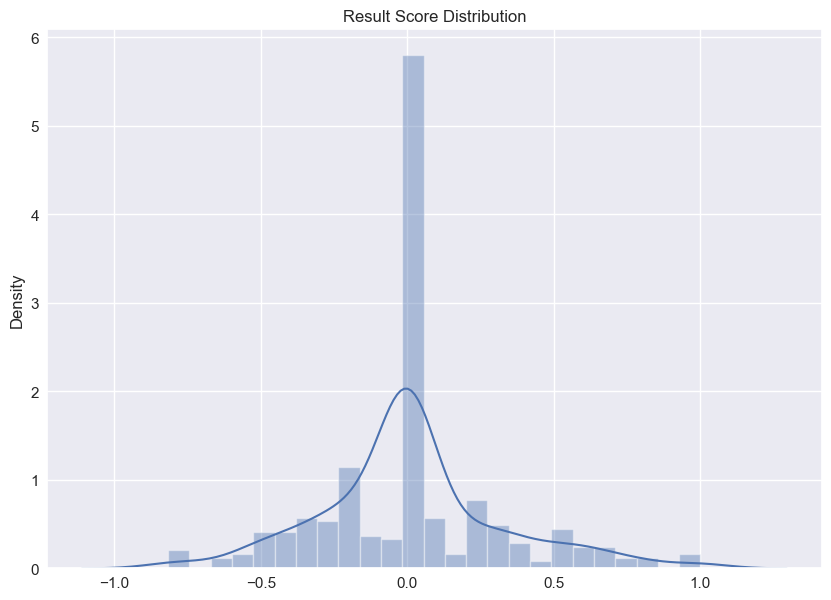

count    337.000000
mean       0.011173
std        0.314002
min       -0.816497
25%       -0.166667
50%        0.000000
75%        0.089087
max        1.000000
dtype: float64

In [23]:
plot_scores(scores)
pd.Series(scores).describe()

<AxesSubplot: xlabel='Date'>

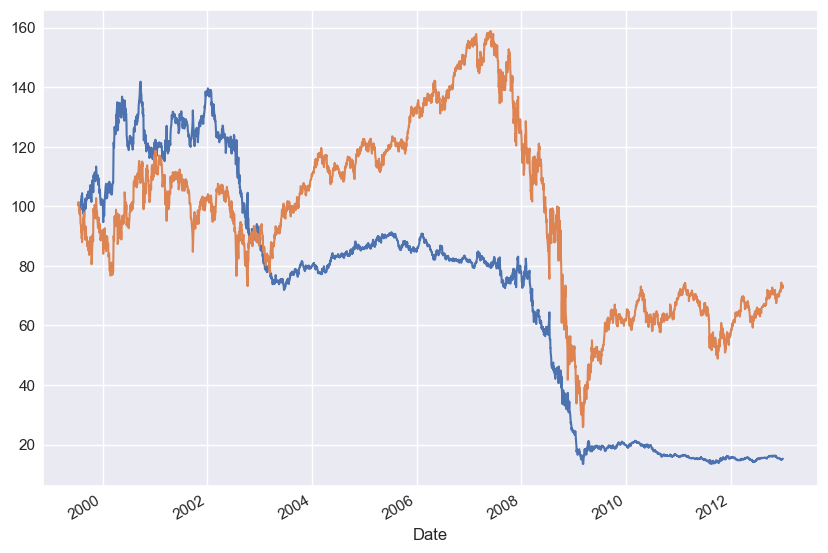

In [24]:
equity_curve.plot()
benchmark.plot()

                           Strategy    Benchmark
-------------------------  ----------  -----------
Start Period               1999-07-15  1999-07-15
End Period                 2012-12-31  2012-12-31
Risk-Free Rate             0.0%        0.0%
Time in Market             99.0%       99.0%

Cumulative Return          -84.81%     -27.2%
CAGR﹪                     -13.05%     -2.33%

Sharpe                     -0.48       0.1
Prob. Sharpe Ratio         4.02%       64.61%
Smart Sharpe               -0.47       0.1
Sortino                    -0.66       0.15
Smart Sortino              -0.64       0.14
Sortino/√2                 -0.47       0.11
Smart Sortino/√2           -0.45       0.1
Omega                      0.91        0.91

Max Drawdown               -90.5%      -83.71%
Longest DD Days            4483        2037
Volatility (ann.)          23.58%      34.39%
R^2                        0.01        0.01
Information Ratio          -0.02       -0.02
Calmar                     -0.14       -

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2000-09-22,2011-08-22,2012-12-31,4483,-90.502140,-89.990430
2,1999-11-17,2000-01-05,2000-03-16,120,-16.463332,-15.961527
3,2000-05-16,2000-06-30,2000-09-15,122,-13.125200,-12.996033
4,1999-08-11,1999-08-24,1999-09-21,41,-7.968842,-7.834901
5,2000-04-13,2000-04-14,2000-05-15,32,-7.016973,-6.520366


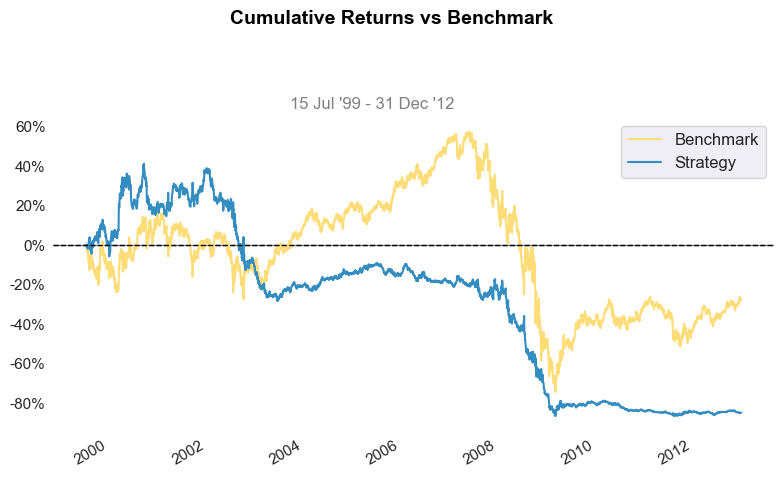

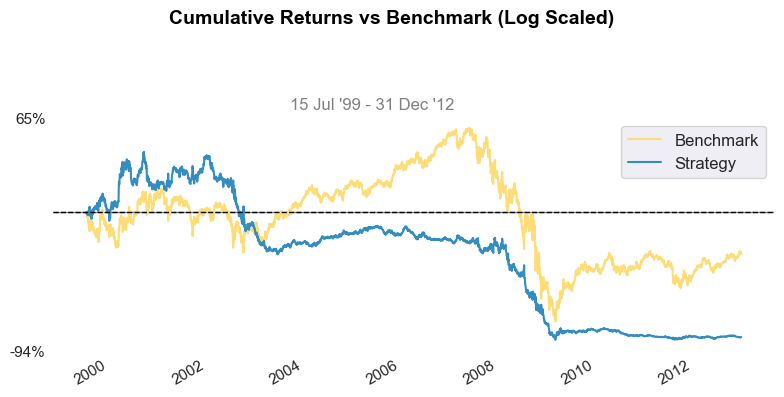

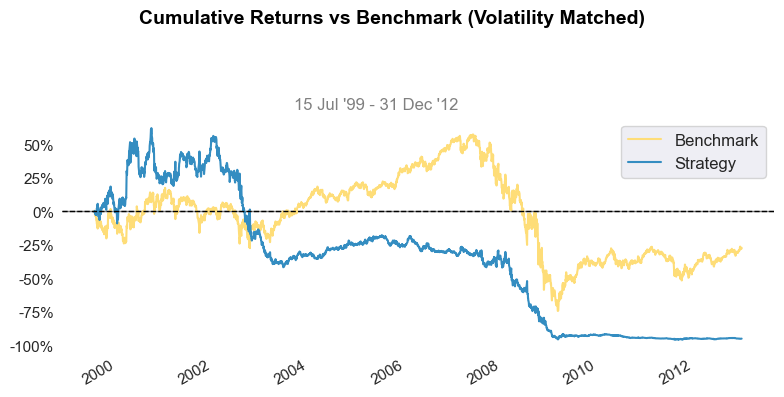

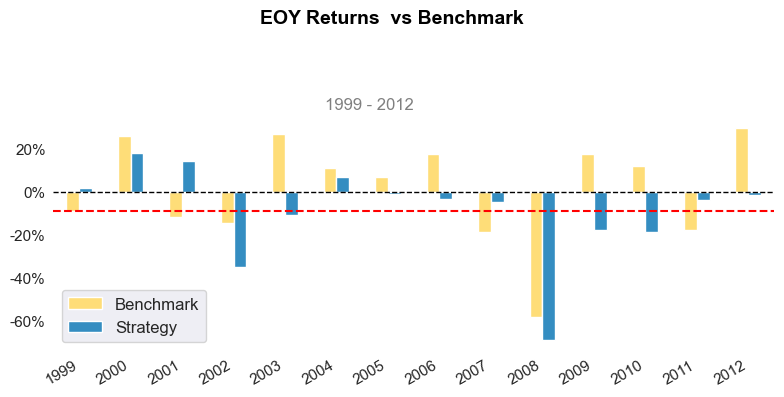

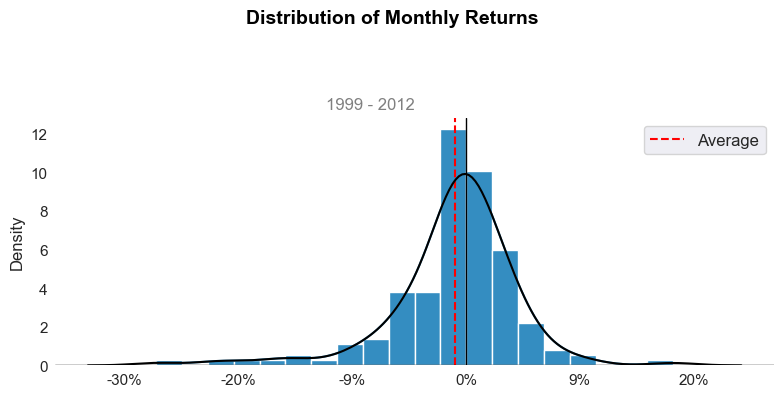

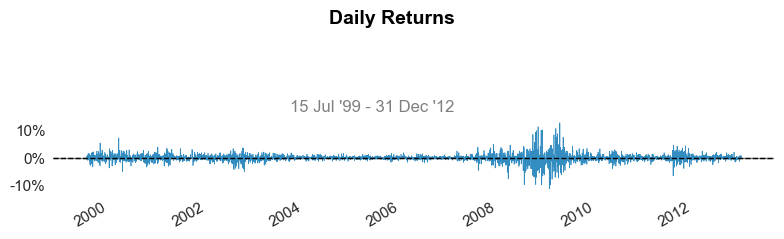

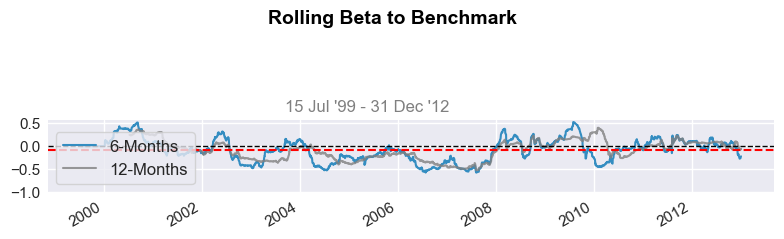

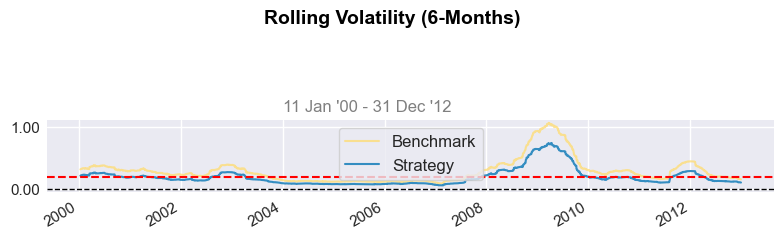

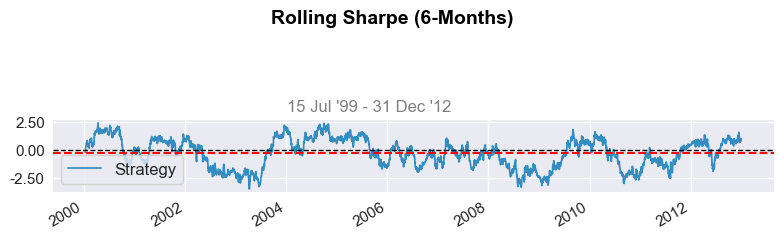

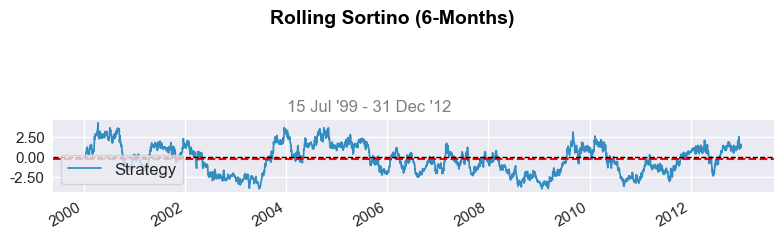

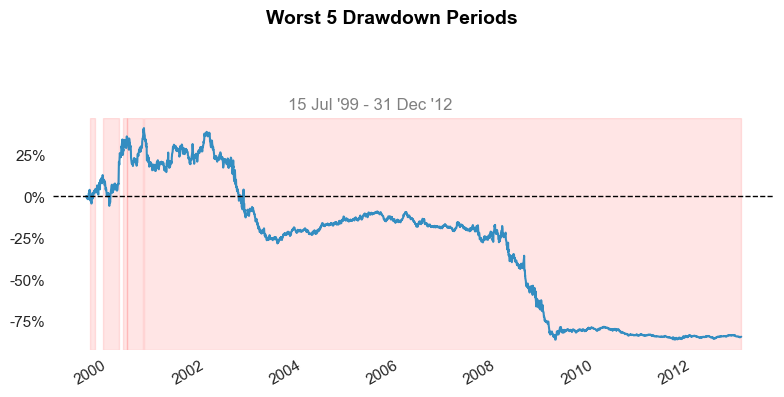

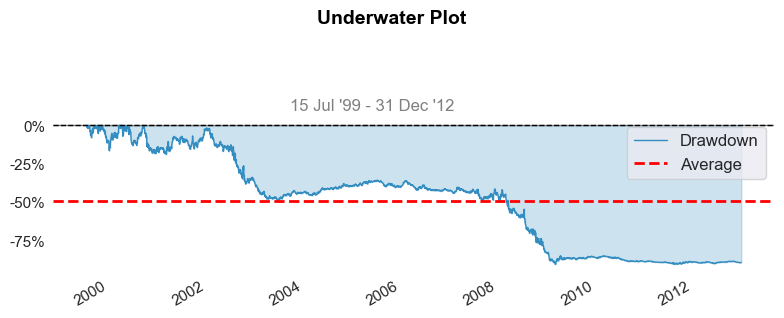

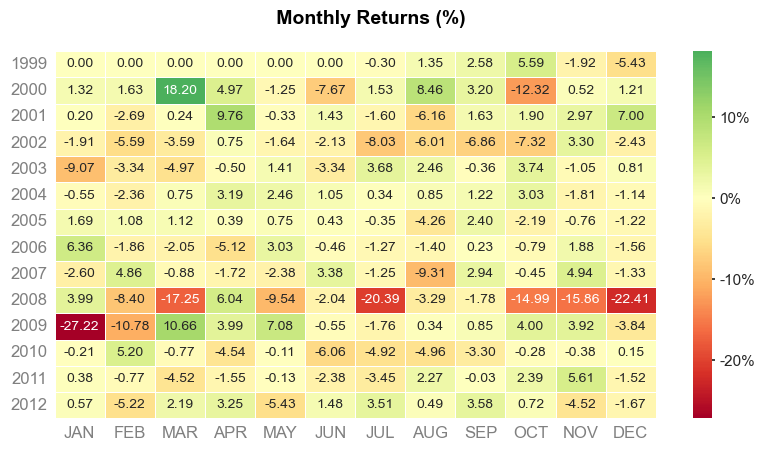

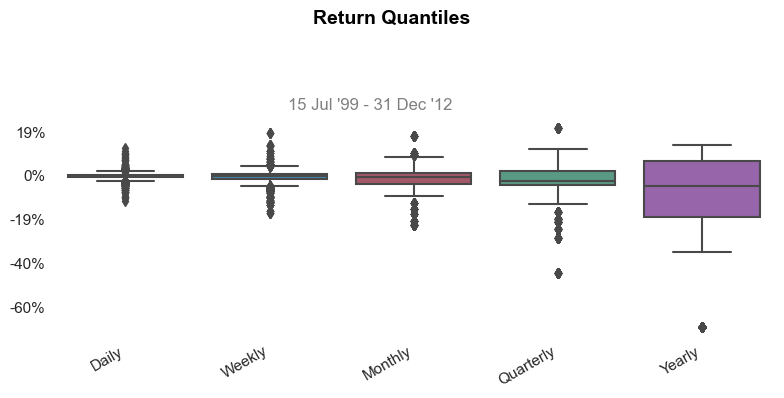

In [25]:
qs.reports.full(remove_timezone(equity_curve), remove_timezone(benchmark))

# Build a More Advanced Model

In this model we will add lots of technical analysis features

In [26]:
# Add all ta features
technical_features = (
    add_all_ta_features(
        df_train.copy(), open="open", high="high", low="low", close="close", volume="volume"
    )
    .ffill()
    .dropna()
)

In [27]:
cprint(technical_features)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                                open       high        low      close  volume  \
Date                                                                            
1999-04-07 00:00:00-04:00  12.874288  13.165633  12.866413  13.102639  324738   
1999-04-09 00:00:00-04:00  13.291625  13.386115  13.165638  13.307373  151167   
1999-04-12 00:00:00-04:00  13.228626  13.559341  13.212877  13.543593  193759   
1999-04-13 00:00:00-04:00  13.701078  13.701078  13.496349  13.527845  209516   
1999-04-14 00:00:00-04:00  13.606590  13.716829  13.354616  13.354616  160646   

                           fwd_8     volume_adi  volume_obv  volume_cmf  \
Date                                                                      
1999-04-07 00:00:00-04:00   -1.0   65729.629692     1484460   -0.017156   
1999-04-

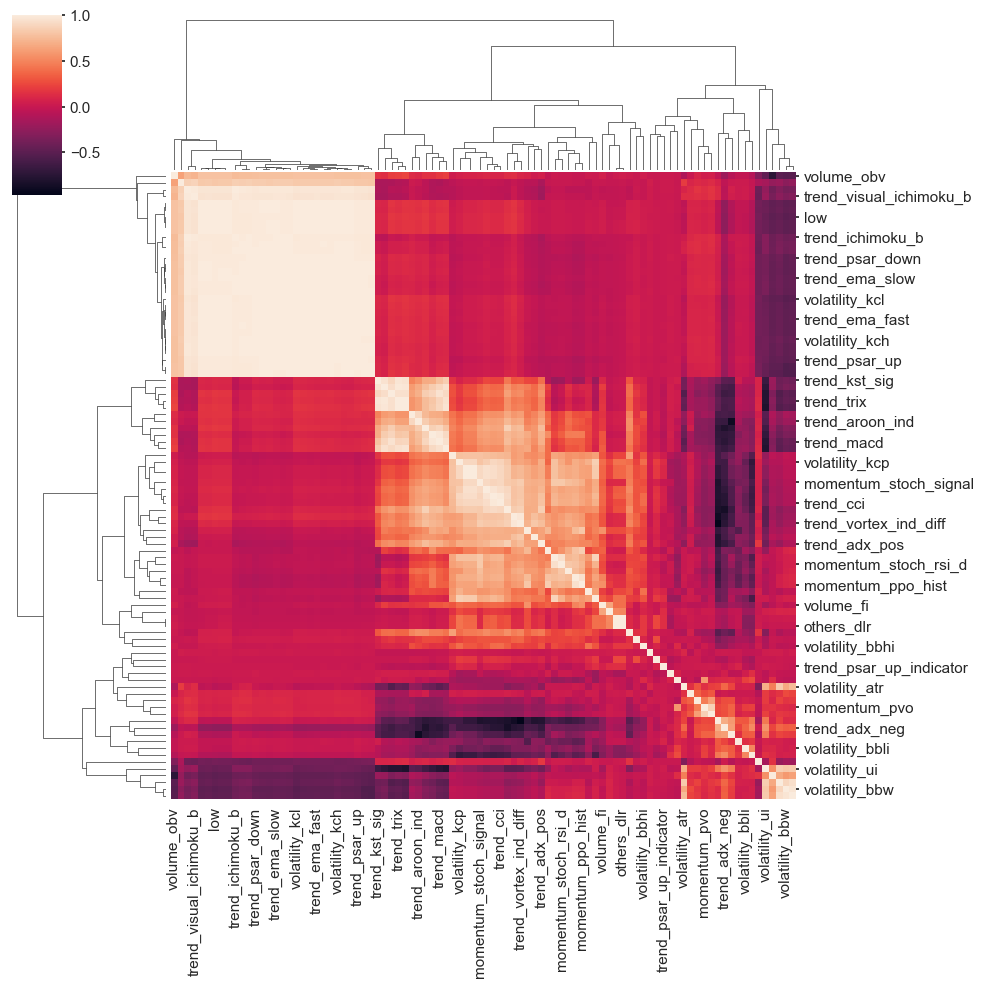

In [28]:
sns.clustermap(technical_features.corr())

In [29]:
drop_cols = ["open", "high", "low", "close", "volume"]
Xdf = technical_features.drop(drop_cols, axis=1)
cprint(Xdf)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                           fwd_8     volume_adi  volume_obv  volume_cmf  \
Date                                                                      
1999-04-07 00:00:00-04:00   -1.0   65729.629692     1484460   -0.017156   
1999-04-09 00:00:00-04:00   -1.0  108919.389847     1635627   -0.029240   
1999-04-12 00:00:00-04:00   -1.0  285064.597027     1829386    0.026873   
1999-04-13 00:00:00-04:00   -1.0  140014.872272     1619870   -0.016284   
1999-04-14 00:00:00-04:00   -1.0  -20631.127728     1459224   -0.068971   

                              volume_fi  volume_em  volume_sma_em  \
Date                                                                
1999-04-07 00:00:00-04:00  12571.865578  16.324091       9.207207   
1999-04-09 00:00:00-04:00  15197.170736  37.899711       9.926184   

## make xy with new features

In [30]:
FEAT_COLS = [x for x in Xdf.columns if "fwd" not in x]
X, y = create_Xy(Xdf, FEAT_COLS, Y_TARGET_COL)
cprint(X)
cprint(y)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                              volume_adi  volume_obv  volume_cmf  \
Date                                                               
1999-04-07 00:00:00-04:00   65729.629692     1484460   -0.017156   
1999-04-09 00:00:00-04:00  108919.389847     1635627   -0.029240   
1999-04-12 00:00:00-04:00  285064.597027     1829386    0.026873   
1999-04-13 00:00:00-04:00  140014.872272     1619870   -0.016284   
1999-04-14 00:00:00-04:00  -20631.127728     1459224   -0.068971   

                              volume_fi  volume_em  volume_sma_em  \
Date                                                                
1999-04-07 00:00:00-04:00  12571.865578  16.324091       9.207207   
1999-04-09 00:00:00-04:00  15197.170736  37.899711       9.926184   
1999-04-12 00:00:00-04:00  19564.692159  19.7108

## run walkforward test

In [31]:
# walkforward test
scores, predictions = walkforward_with_purging_and_embargos(
    model=create_model(),
    X=X,
    y=y,
    purged_window_size=0,
    embargo_period=2,
    lookback=100,
    test_size=10,
    scaler=StandardScaler(),
    scorer=matthews_corrcoef,
)

*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-09-23 00:00:00-04:00
test index:: start: 1999-09-24 00:00:00-04:00 end: 1999-10-07 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-09-21 00:00:00-04:00
test index:: start: 1999-09-24 00:00:00-04:00 end: 1999-10-07 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-10-07 00:00:00-04:00
test index:: start: 1999-10-08 00:00:00-04:00 end: 1999-10-21 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-10-05 00:00:00-04:00
test index:: start: 1999-10-08 00:00:00-04:00 end: 1999-10-21 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-10-21 00:00:00-04:00
test index:: start: 1999-1

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-06-21 00:00:00-04:00
test index:: start: 2000-06-26 00:00:00-04:00 end: 2000-07-10 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-07-10 00:00:00-04:00
test index:: start: 2000-07-11 00:00:00-04:00 end: 2000-07-24 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-07-06 00:00:00-04:00
test index:: start: 2000-07-11 00:00:00-04:00 end: 2000-07-24 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-07-24 00:00:00-04:00
test index:: start: 2000-07-25 00:00:00-04:00 end: 2000-08-07 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-07-20 00:00:00-04:00
test index:: start: 2000-07-25 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-04-06 00:00:00-04:00
test index:: start: 2001-04-11 00:00:00-04:00 end: 2001-04-25 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-04-25 00:00:00-04:00
test index:: start: 2001-04-26 00:00:00-04:00 end: 2001-05-09 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-04-23 00:00:00-04:00
test index:: start: 2001-04-26 00:00:00-04:00 end: 2001-05-09 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-05-09 00:00:00-04:00
test index:: start: 2001-05-10 00:00:00-04:00 end: 2001-05-24 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-05-07 00:00:00-04:00
test index:: start: 2001-05-10 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-01-30 00:00:00-05:00
test index:: start: 2002-02-04 00:00:00-05:00 end: 2002-02-15 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-02-15 00:00:00-05:00
test index:: start: 2002-02-19 00:00:00-05:00 end: 2002-03-04 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-02-13 00:00:00-05:00
test index:: start: 2002-02-19 00:00:00-05:00 end: 2002-03-04 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-03-04 00:00:00-05:00
test index:: start: 2002-03-05 00:00:00-05:00 end: 2002-03-18 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-02-28 00:00:00-05:00
test index:: start: 2002-03-05 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-11-13 00:00:00-05:00
test index:: start: 2002-11-18 00:00:00-05:00 end: 2002-12-02 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-12-02 00:00:00-05:00
test index:: start: 2002-12-03 00:00:00-05:00 end: 2002-12-16 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-11-27 00:00:00-05:00
test index:: start: 2002-12-03 00:00:00-05:00 end: 2002-12-16 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-12-16 00:00:00-05:00
test index:: start: 2002-12-17 00:00:00-05:00 end: 2002-12-31 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-12-12 00:00:00-05:00
test index:: start: 2002-12-17 0

...

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-04-09 00:00:00-04:00
test index:: start: 2009-04-15 00:00:00-04:00 end: 2009-04-28 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-04-28 00:00:00-04:00
test index:: start: 2009-04-29 00:00:00-04:00 end: 2009-05-12 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-04-24 00:00:00-04:00
test index:: start: 2009-04-29 00:00:00-04:00 end: 2009-05-12 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-05-12 00:00:00-04:00
test index:: start: 2009-05-13 00:00:00-04:00 end: 2009-05-27 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-05-08 00:00:00-04:00
test index:: start: 2009-05-13 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-01-26 00:00:00-05:00
test index:: start: 2010-01-29 00:00:00-05:00 end: 2010-02-11 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-02-11 00:00:00-05:00
test index:: start: 2010-02-12 00:00:00-05:00 end: 2010-02-26 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-02-09 00:00:00-05:00
test index:: start: 2010-02-12 00:00:00-05:00 end: 2010-02-26 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-02-26 00:00:00-05:00
test index:: start: 2010-03-01 00:00:00-05:00 end: 2010-03-12 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-02-24 00:00:00-05:00
test index:: start: 2010-03-01 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-11-09 00:00:00-05:00
test index:: start: 2010-11-12 00:00:00-05:00 end: 2010-11-26 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-11-26 00:00:00-05:00
test index:: start: 2010-11-29 00:00:00-05:00 end: 2010-12-10 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-11-23 00:00:00-05:00
test index:: start: 2010-11-29 00:00:00-05:00 end: 2010-12-10 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-12-10 00:00:00-05:00
test index:: start: 2010-12-13 00:00:00-05:00 end: 2010-12-27 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-12-08 00:00:00-05:00
test index:: start: 2010-12-13 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-08-29 00:00:00-04:00
test index:: start: 2011-09-01 00:00:00-04:00 end: 2011-09-15 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-09-15 00:00:00-04:00
test index:: start: 2011-09-16 00:00:00-04:00 end: 2011-09-29 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-09-13 00:00:00-04:00
test index:: start: 2011-09-16 00:00:00-04:00 end: 2011-09-29 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-09-29 00:00:00-04:00
test index:: start: 2011-09-30 00:00:00-04:00 end: 2011-10-13 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-09-27 00:00:00-04:00
test index:: start: 2011-09-30 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-06-15 00:00:00-04:00
test index:: start: 2012-06-20 00:00:00-04:00 end: 2012-07-03 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-07-03 00:00:00-04:00
test index:: start: 2012-07-05 00:00:00-04:00 end: 2012-07-19 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-06-29 00:00:00-04:00
test index:: start: 2012-07-05 00:00:00-04:00 end: 2012-07-19 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-07-19 00:00:00-04:00
test index:: start: 2012-07-20 00:00:00-04:00 end: 2012-08-02 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-07-16 00:00:00-04:00
test index:: start: 2012-07-20 0

## evaluate results

In [32]:
# evaluate results
STARTING_VALUE = 100
equity_curve, equity_returns = get_estimated_backtests(
    predictions, actual_returns, starting_value=STARTING_VALUE
)
benchmark = returns_to_index(
    actual_returns.loc[equity_curve.index], starting_value=STARTING_VALUE
)

In [33]:
update_agg_results(hdf_store_fp, "ta_model", scores, equity_curve, equity_returns)

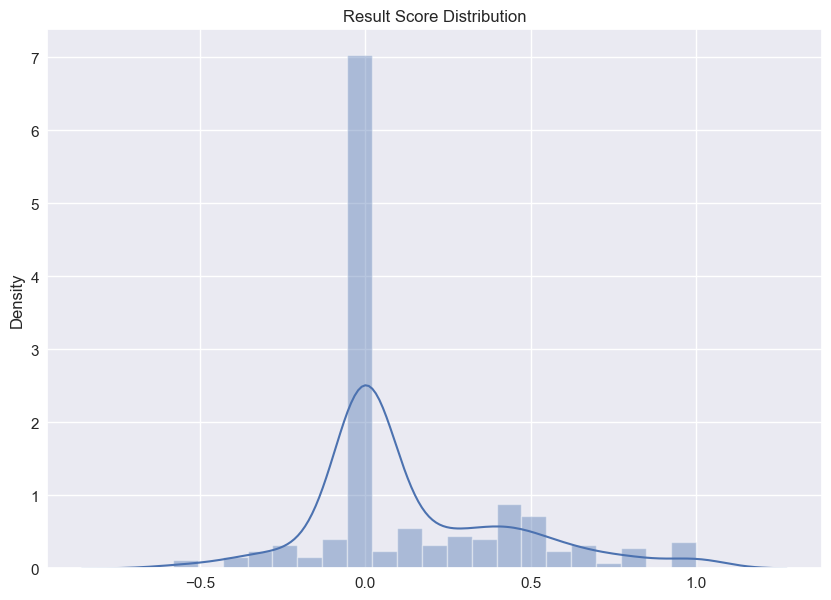

<AxesSubplot: xlabel='Date'>

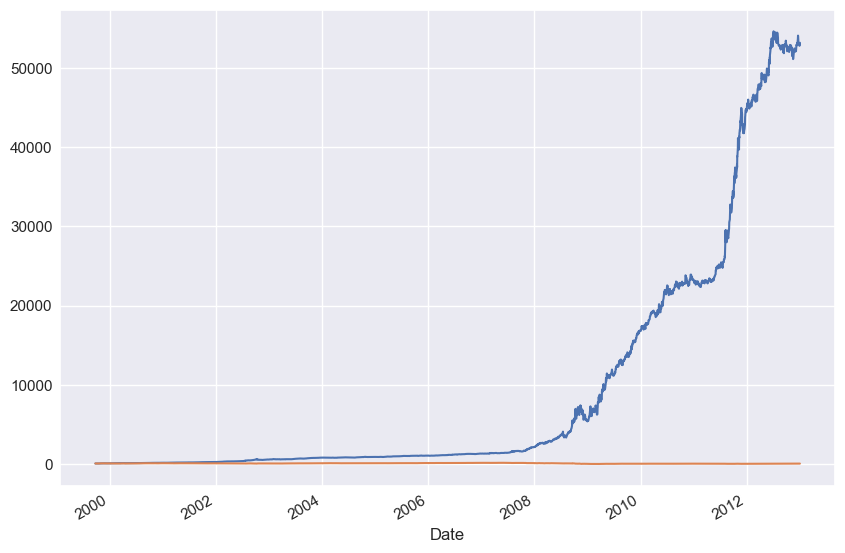

In [34]:
plot_scores(scores)
pd.Series(scores).describe()

equity_curve.plot()
benchmark.plot()

                           Strategy     Benchmark
-------------------------  -----------  -----------
Start Period               1999-09-24   1999-09-24
End Period                 2012-12-31   2012-12-31
Risk-Free Rate             0.0%         0.0%
Time in Market             99.0%        99.0%

Cumulative Return          52,750.14%   -14.46%
CAGR﹪                     60.35%       -1.17%

Sharpe                     2.31         0.14
Prob. Sharpe Ratio         100.0%       69.15%
Smart Sharpe               2.15         0.13
Sortino                    3.76         0.2
Smart Sortino              3.51         0.19
Sortino/√2                 2.66         0.14
Smart Sortino/√2           2.48         0.13
Omega                      1.62         1.62

Max Drawdown               -27.26%      -83.71%
Longest DD Days            179          2037
Volatility (ann.)          21.68%       34.49%
R^2                        0.05         0.05
Information Ratio          0.06         0.06
Calmar           

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2008-11-13,2008-12-30,2009-03-12,119,-27.264548,-26.120251
2,2008-07-16,2008-08-06,2008-08-28,43,-18.099048,-17.726592
3,2008-10-10,2008-10-14,2008-10-24,14,-17.729109,-13.664219
4,2002-10-10,2002-11-14,2003-01-31,113,-16.443483,-15.973822
5,2008-10-28,2008-11-04,2008-11-12,15,-14.069661,-10.646552


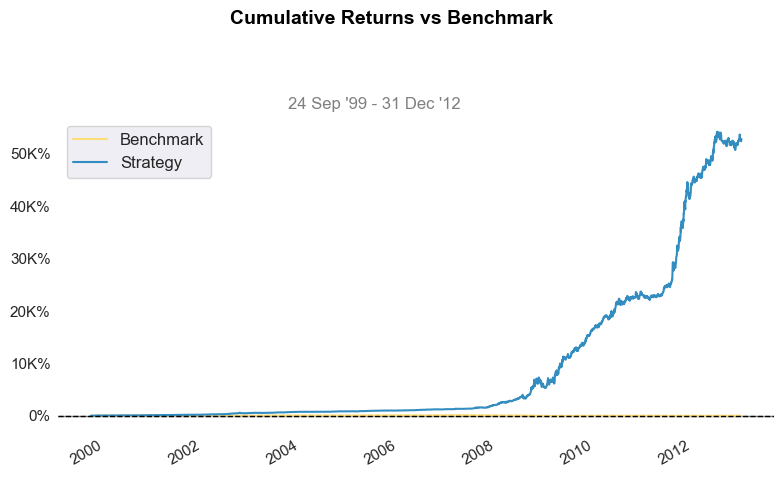

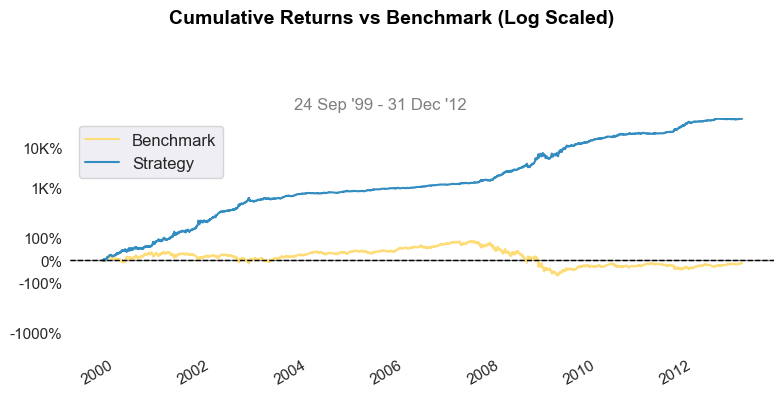

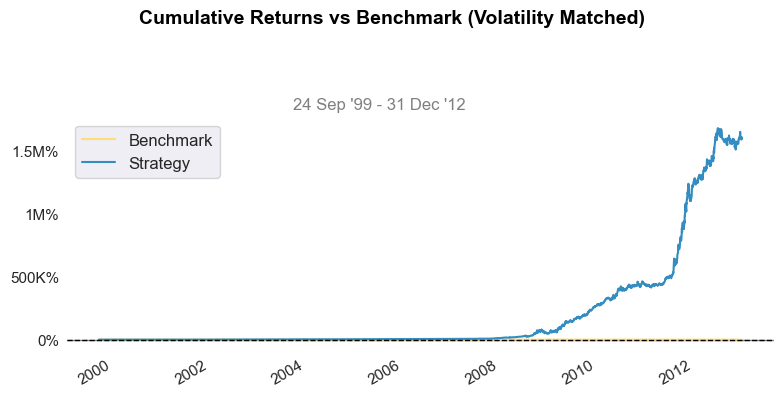

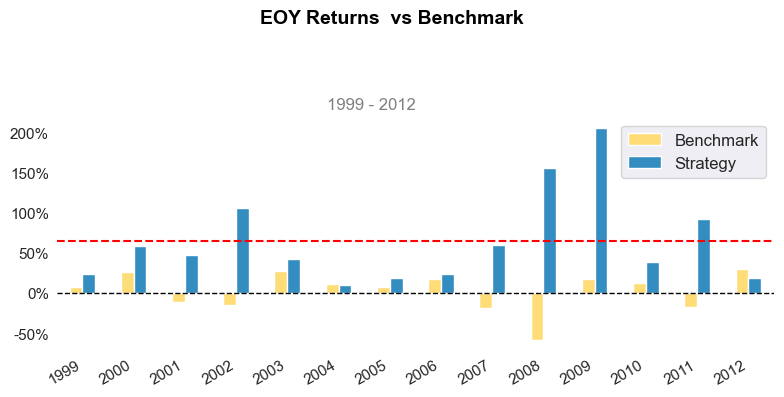

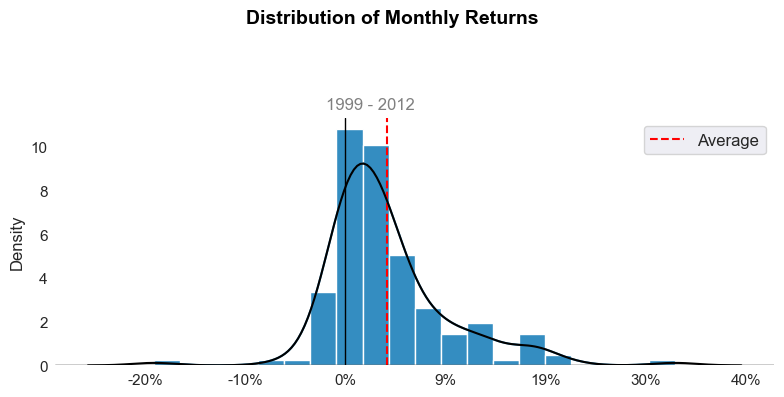

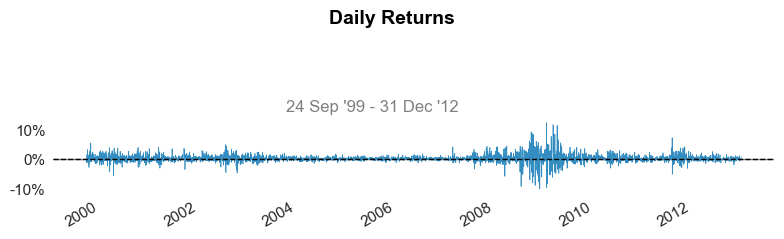

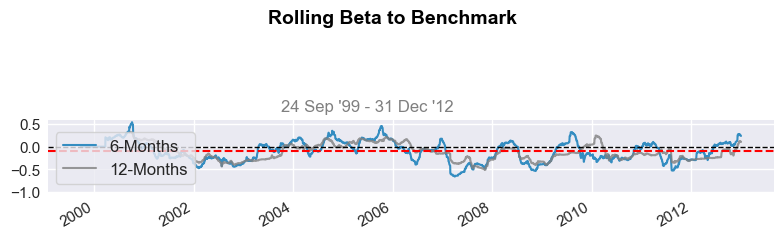

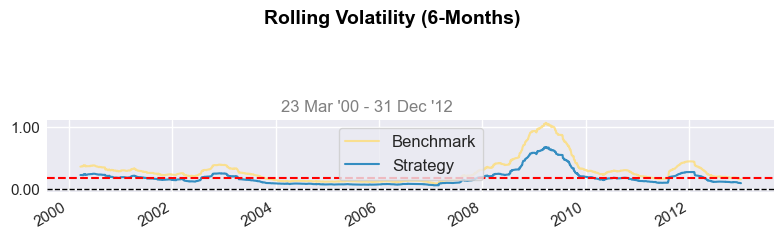

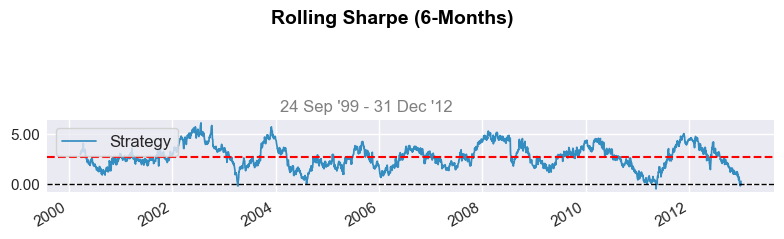

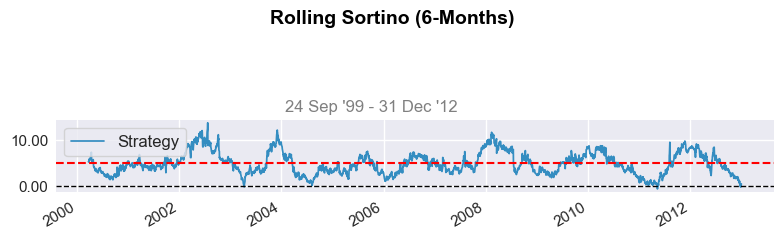

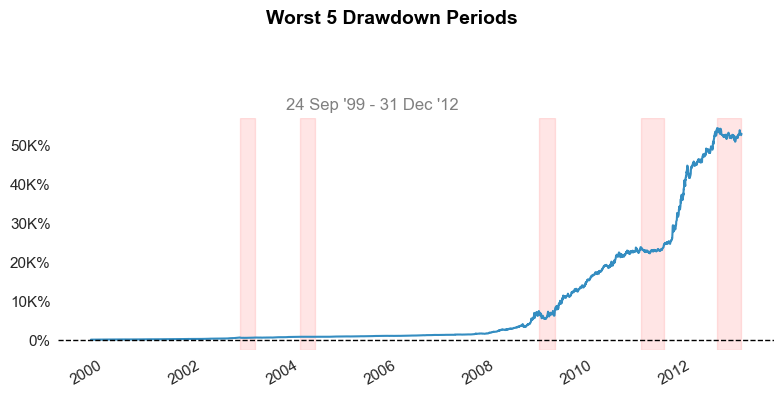

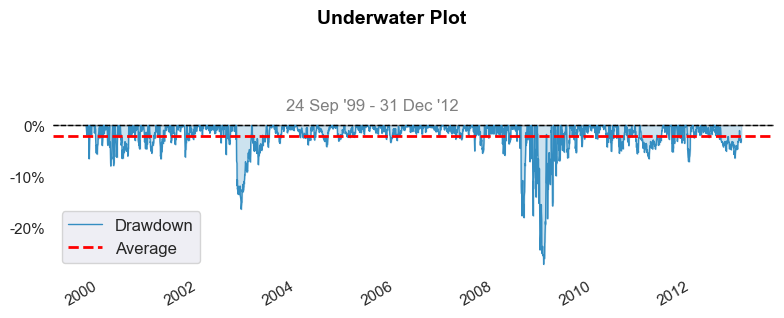

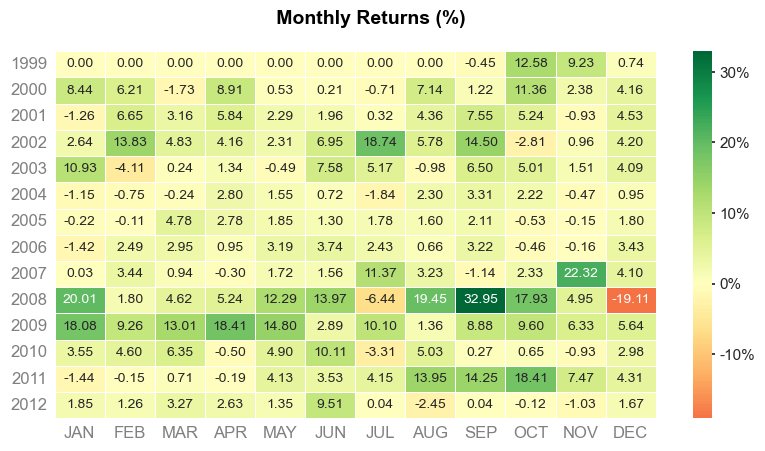

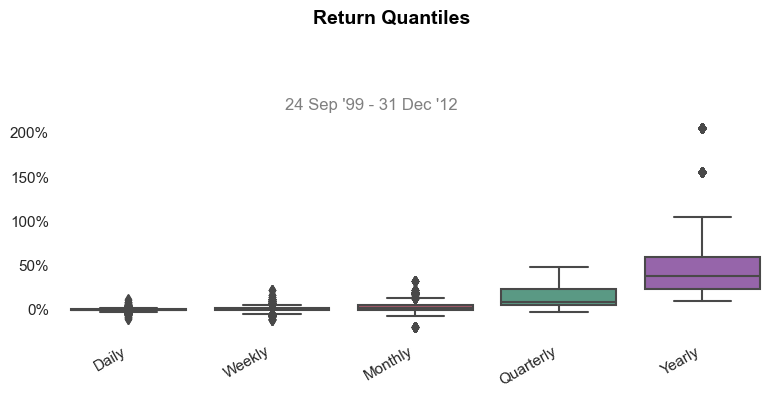

In [35]:
qs.reports.full(remove_timezone(equity_curve), remove_timezone(benchmark))

# Build a Model With Market Microstructure features

In [36]:
def add_market_microstructure_features(indf, window):
    out_df = indf.copy()

    # add acf feature
    out_df["acf"] = (
        out_df["close"]
        .rolling(window)
        .apply(lambda x: acf(x, adjusted=True, fft=False)[1], raw=True)
    )
    # timeseries topographical
    out_df["permutation_entropy"] = (
        out_df["close"]
        .rolling(window)
        .apply(lambda x: permutation_entropy(x, 3), raw=True)
    )
    out_df["hurst"] = (
        out_df["close"].rolling(window).apply(lambda x: hurst(x), raw=True)
    )

    out_df["kyles_lambda"] = kyles_lambda(
        out_df["close"], out_df["volume"], window=window
    )
    out_df["bekker_parkinson_vol"] = bekker_parkinson_vol(
        out_df["high"], out_df["low"], out_df["close"], window=window
    )

    out_df["corwin_schultz_hl"] = corwin_schultz_hl(
        out_df["high"], out_df["low"], out_df["volume"], window=window
    )

    out_df["amihuds_lambda"] = amihuds_lambda(
        out_df["close"], out_df["volume"], window=window
    )

    out_df["hb_lambda"] = hasbroucks_lambda(
        out_df["close"], out_df["volume"], window=window
    )

    out_df["roll_measure"] = roll_measure(out_df["close"], window=window)
    return out_df.ffill().dropna()

## add features

In [37]:
drop_cols = ["open", "high", "low", "close", "volume"]
Xdf = add_market_microstructure_features(df_train, window=WINDOW).drop(
    drop_cols, axis=1
)
cprint(Xdf)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                           fwd_8       acf  permutation_entropy     hurst  \
Date                                                                        
1999-03-19 00:00:00-05:00    1.0  0.919635             1.829605 -0.708549   
1999-03-22 00:00:00-05:00    1.0  0.907482             1.779763 -0.679467   
1999-03-23 00:00:00-05:00   -1.0  0.878901             1.779763 -0.590862   
1999-03-24 00:00:00-05:00   -1.0  0.859649             1.829605 -0.544895   
1999-03-25 00:00:00-05:00   -1.0  0.891697             1.829605 -0.541364   

                           kyles_lambda  bekker_parkinson_vol  \
Date                                                            
1999-03-19 00:00:00-05:00     -1.704925              0.014964   
1999-03-22 00:00:00-05:00     -1.700362              0.014964   
1

In [38]:
FEAT_COLS = [x for x in Xdf.columns if "fwd" not in x]
X, y = create_Xy(Xdf, FEAT_COLS, Y_TARGET_COL)
cprint(X)
cprint(y)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                                acf  permutation_entropy     hurst  \
Date                                                                 
1999-03-19 00:00:00-05:00  0.919635             1.829605 -0.708549   
1999-03-22 00:00:00-05:00  0.907482             1.779763 -0.679467   
1999-03-23 00:00:00-05:00  0.878901             1.779763 -0.590862   
1999-03-24 00:00:00-05:00  0.859649             1.829605 -0.544895   
1999-03-25 00:00:00-05:00  0.891697             1.829605 -0.541364   

                           kyles_lambda  bekker_parkinson_vol  \
Date                                                            
1999-03-19 00:00:00-05:00     -1.704925              0.014964   
1999-03-22 00:00:00-05:00     -1.700362              0.014964   
1999-03-23 00:00:00-05:00     -1.727359           

## run walkforward test

In [39]:
scores, predictions = walkforward_with_purging_and_embargos(
    model=create_model(),
    X=X,
    y=y,
    purged_window_size=0,
    embargo_period=2,
    lookback=100,
    test_size=10,
    scaler=StandardScaler(),
    scorer=matthews_corrcoef,
)

*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 1999-08-25 00:00:00-04:00
test index:: start: 1999-08-26 00:00:00-04:00 end: 1999-09-09 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 1999-08-23 00:00:00-04:00
test index:: start: 1999-08-26 00:00:00-04:00 end: 1999-09-09 00:00:00-04:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 1999-09-09 00:00:00-04:00
test index:: start: 1999-09-10 00:00:00-04:00 end: 1999-09-23 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 1999-09-07 00:00:00-04:00
test index:: start: 1999-09-10 00:00:00-04:00 end: 1999-09-23 00:00:00-04:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 1999-09-23 00:00:00-04:00
test index:: start: 1999-0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2000-05-23 00:00:00-04:00
test index:: start: 2000-05-26 00:00:00-04:00 end: 2000-06-09 00:00:00-04:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2000-06-09 00:00:00-04:00
test index:: start: 2000-06-12 00:00:00-04:00 end: 2000-06-23 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2000-06-07 00:00:00-04:00
test index:: start: 2000-06-12 00:00:00-04:00 end: 2000-06-23 00:00:00-04:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2000-06-23 00:00:00-04:00
test index:: start: 2000-06-26 00:00:00-04:00 end: 2000-07-10 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2000-06-21 00:00:00-04:00
test index:: start: 2000-06-26 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2001-03-09 00:00:00-05:00
test index:: start: 2001-03-14 00:00:00-05:00 end: 2001-03-27 00:00:00-05:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2001-03-27 00:00:00-05:00
test index:: start: 2001-03-28 00:00:00-05:00 end: 2001-04-10 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2001-03-23 00:00:00-05:00
test index:: start: 2001-03-28 00:00:00-05:00 end: 2001-04-10 00:00:00-04:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2001-04-10 00:00:00-04:00
test index:: start: 2001-04-11 00:00:00-04:00 end: 2001-04-25 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2001-04-06 00:00:00-04:00
test index:: start: 2001-04-11 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2001-12-31 00:00:00-05:00
test index:: start: 2002-01-04 00:00:00-05:00 end: 2002-01-17 00:00:00-05:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2002-01-17 00:00:00-05:00
test index:: start: 2002-01-18 00:00:00-05:00 end: 2002-02-01 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2002-01-15 00:00:00-05:00
test index:: start: 2002-01-18 00:00:00-05:00 end: 2002-02-01 00:00:00-05:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2002-02-01 00:00:00-05:00
test index:: start: 2002-02-04 00:00:00-05:00 end: 2002-02-15 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2002-01-30 00:00:00-05:00
test index:: start: 2002-02-04 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2002-10-16 00:00:00-04:00
test index:: start: 2002-10-21 00:00:00-04:00 end: 2002-11-01 00:00:00-05:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2002-11-01 00:00:00-05:00
test index:: start: 2002-11-04 00:00:00-05:00 end: 2002-11-15 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2002-10-30 00:00:00-05:00
test index:: start: 2002-11-04 00:00:00-05:00 end: 2002-11-15 00:00:00-05:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2002-11-15 00:00:00-05:00
test index:: start: 2002-11-18 00:00:00-05:00 end: 2002-12-02 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2002-11-13 00:00:00-05:00
test index:: start: 2002-11-18 0

...

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2009-03-12 00:00:00-04:00
test index:: start: 2009-03-17 00:00:00-04:00 end: 2009-03-30 00:00:00-04:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2009-03-30 00:00:00-04:00
test index:: start: 2009-03-31 00:00:00-04:00 end: 2009-04-14 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2009-03-26 00:00:00-04:00
test index:: start: 2009-03-31 00:00:00-04:00 end: 2009-04-14 00:00:00-04:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2009-04-14 00:00:00-04:00
test index:: start: 2009-04-15 00:00:00-04:00 end: 2009-04-28 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2009-04-09 00:00:00-04:00
test index:: start: 2009-04-15 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2009-12-24 00:00:00-05:00
test index:: start: 2009-12-30 00:00:00-05:00 end: 2010-01-13 00:00:00-05:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2010-01-13 00:00:00-05:00
test index:: start: 2010-01-14 00:00:00-05:00 end: 2010-01-28 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2010-01-11 00:00:00-05:00
test index:: start: 2010-01-14 00:00:00-05:00 end: 2010-01-28 00:00:00-05:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2010-01-28 00:00:00-05:00
test index:: start: 2010-01-29 00:00:00-05:00 end: 2010-02-11 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2010-01-26 00:00:00-05:00
test index:: start: 2010-01-29 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2010-10-12 00:00:00-04:00
test index:: start: 2010-10-15 00:00:00-04:00 end: 2010-10-28 00:00:00-04:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2010-10-28 00:00:00-04:00
test index:: start: 2010-10-29 00:00:00-04:00 end: 2010-11-11 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2010-10-26 00:00:00-04:00
test index:: start: 2010-10-29 00:00:00-04:00 end: 2010-11-11 00:00:00-05:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2010-11-11 00:00:00-05:00
test index:: start: 2010-11-12 00:00:00-05:00 end: 2010-11-26 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2010-11-09 00:00:00-05:00
test index:: start: 2010-11-12 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2011-08-01 00:00:00-04:00
test index:: start: 2011-08-04 00:00:00-04:00 end: 2011-08-17 00:00:00-04:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2011-08-17 00:00:00-04:00
test index:: start: 2011-08-18 00:00:00-04:00 end: 2011-08-31 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2011-08-15 00:00:00-04:00
test index:: start: 2011-08-18 00:00:00-04:00 end: 2011-08-31 00:00:00-04:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2011-08-31 00:00:00-04:00
test index:: start: 2011-09-01 00:00:00-04:00 end: 2011-09-15 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2011-08-29 00:00:00-04:00
test index:: start: 2011-09-01 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2012-05-17 00:00:00-04:00
test index:: start: 2012-05-22 00:00:00-04:00 end: 2012-06-05 00:00:00-04:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2012-06-05 00:00:00-04:00
test index:: start: 2012-06-06 00:00:00-04:00 end: 2012-06-19 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2012-06-01 00:00:00-04:00
test index:: start: 2012-06-06 00:00:00-04:00 end: 2012-06-19 00:00:00-04:00


*******************************************************
train index:: start: 1999-03-19 00:00:00-05:00 end: 2012-06-19 00:00:00-04:00
test index:: start: 2012-06-20 00:00:00-04:00 end: 2012-07-03 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-03-19 00:00:00-05:00 end: 2012-06-15 00:00:00-04:00
test index:: start: 2012-06-20 0

## evaluate results

In [40]:
# evaluate results
STARTING_VALUE = 100
equity_curve, equity_returns = get_estimated_backtests(
    predictions, actual_returns, starting_value=STARTING_VALUE
)
benchmark = returns_to_index(
    actual_returns.loc[equity_curve.index], starting_value=STARTING_VALUE
)

In [41]:
update_agg_results(
    hdf_store_fp, "microstructure_model", scores, equity_curve, equity_returns
)

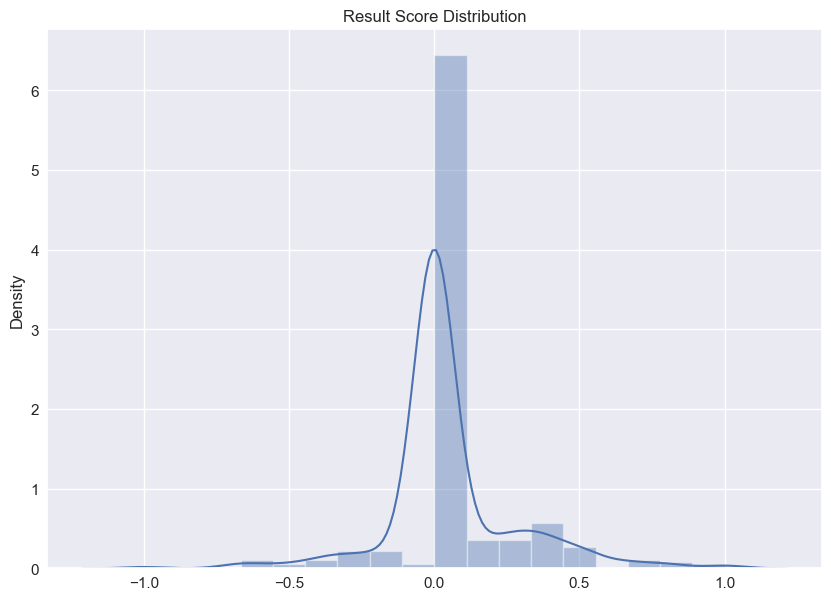

<AxesSubplot: xlabel='Date'>

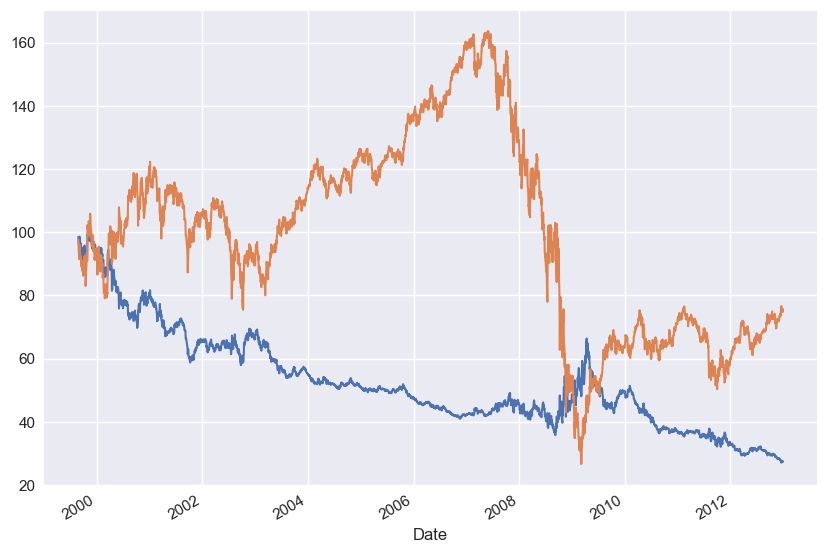

In [42]:
plot_scores(scores)
pd.Series(scores).describe()

equity_curve.plot()
benchmark.plot()

                           Strategy    Benchmark
-------------------------  ----------  -----------
Start Period               1999-08-26  1999-08-26
End Period                 2012-12-31  2012-12-31
Risk-Free Rate             0.0%        0.0%
Time in Market             99.0%       99.0%

Cumulative Return          -72.24%     -22.55%
CAGR﹪                     -9.15%      -1.89%

Sharpe                     -0.32       0.12
Prob. Sharpe Ratio         12.17%      66.36%
Smart Sharpe               -0.31       0.11
Sortino                    -0.46       0.17
Smart Sortino              -0.44       0.16
Sortino/√2                 -0.32       0.12
Smart Sortino/√2           -0.31       0.11
Omega                      0.94        0.94

Max Drawdown               -73.25%     -83.71%
Longest DD Days            4793        2037
Volatility (ann.)          22.33%      34.46%
R^2                        0.0         0.0
Information Ratio          -0.02       -0.02
Calmar                     -0.12     

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,1999-11-17,2012-12-20,2012-12-31,4793,-73.249489,-71.389927
2,1999-09-07,1999-10-15,1999-10-28,51,-9.744292,-7.885149
3,1999-08-27,1999-09-02,1999-09-03,7,-3.681558,-2.818077
4,1999-11-08,1999-11-11,1999-11-16,8,-2.561203,-2.242288
5,1999-10-29,1999-11-03,1999-11-05,7,-1.486077,-1.211893


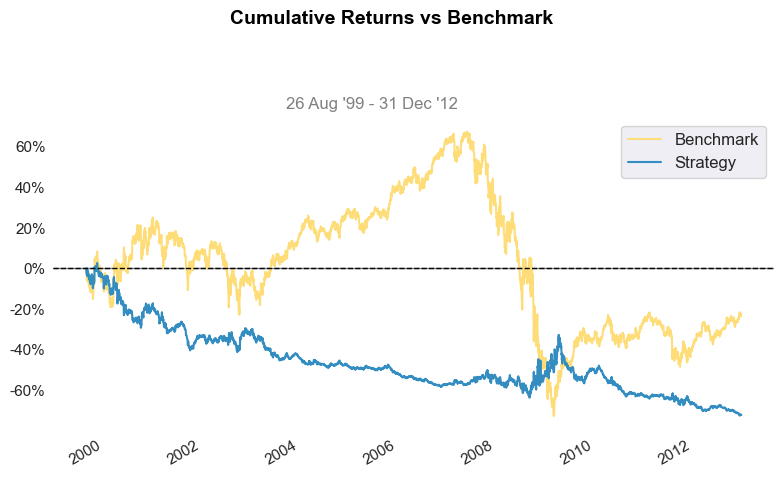

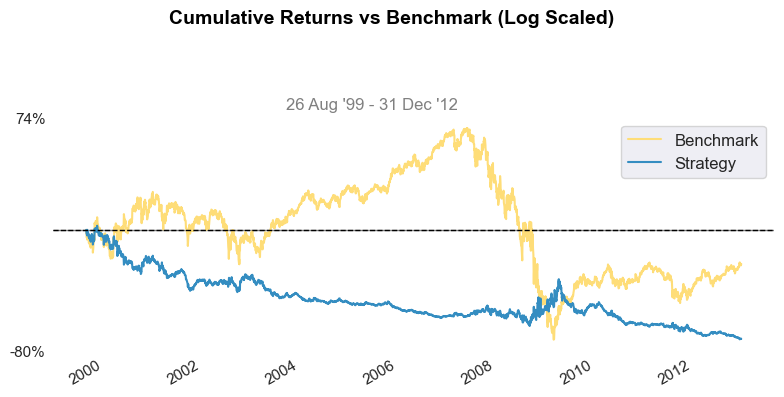

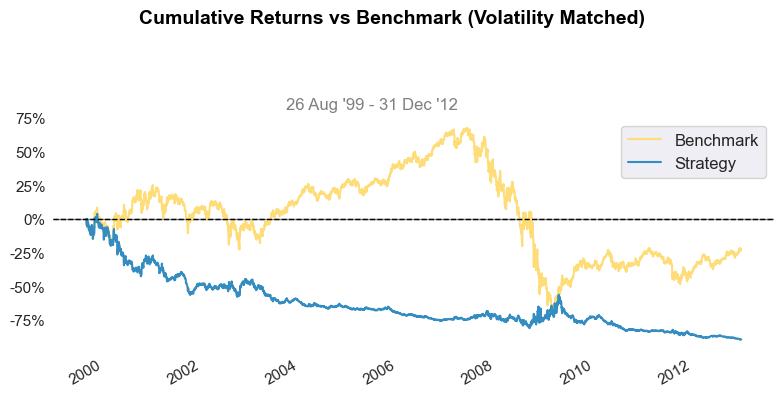

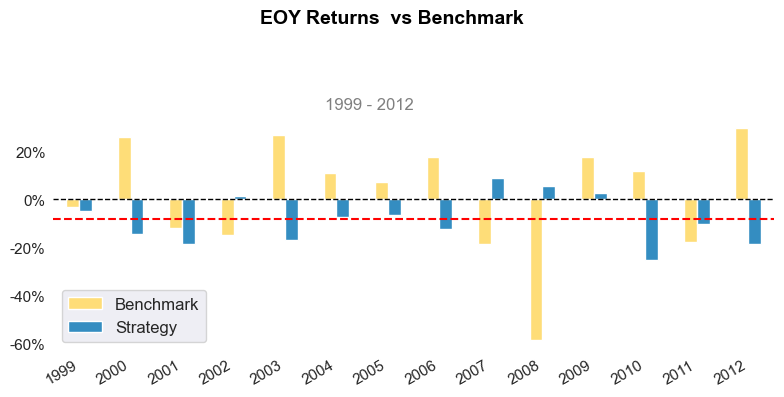

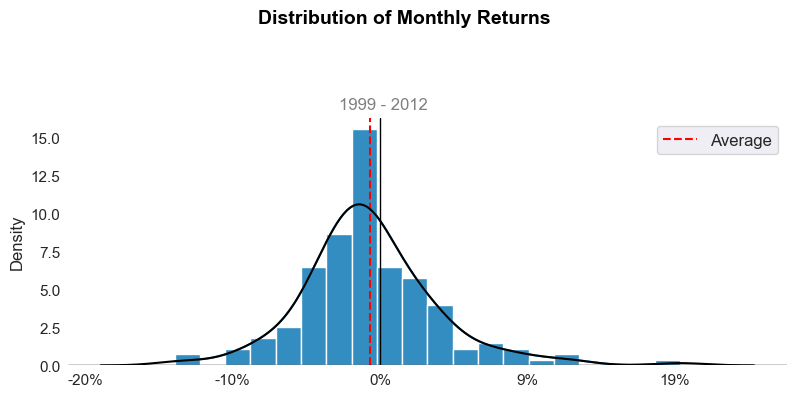

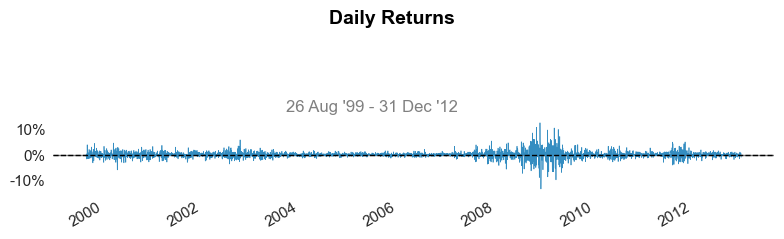

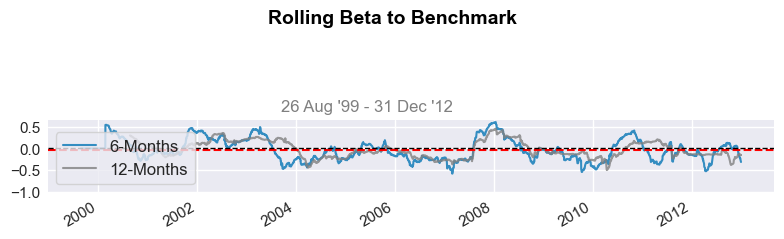

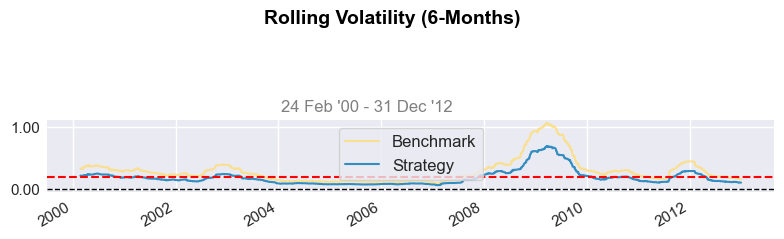

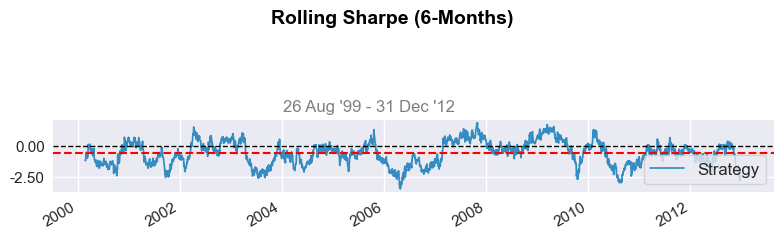

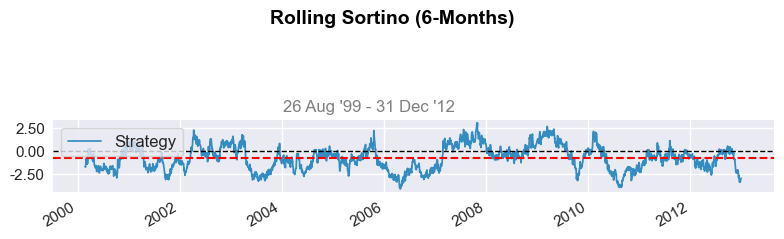

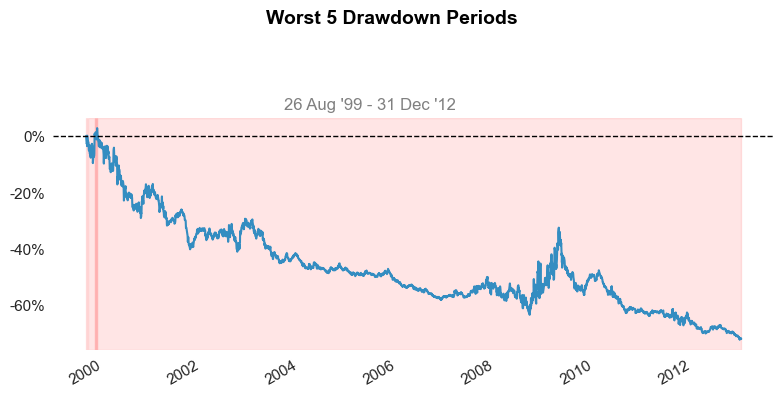

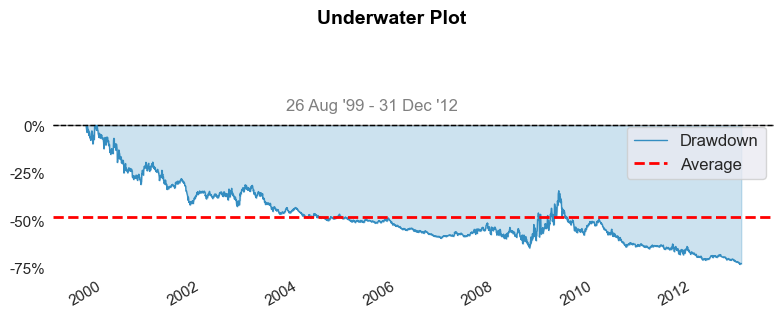

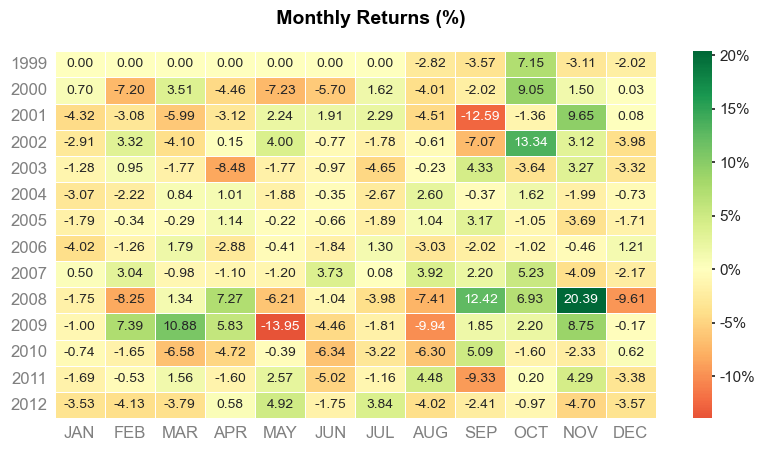

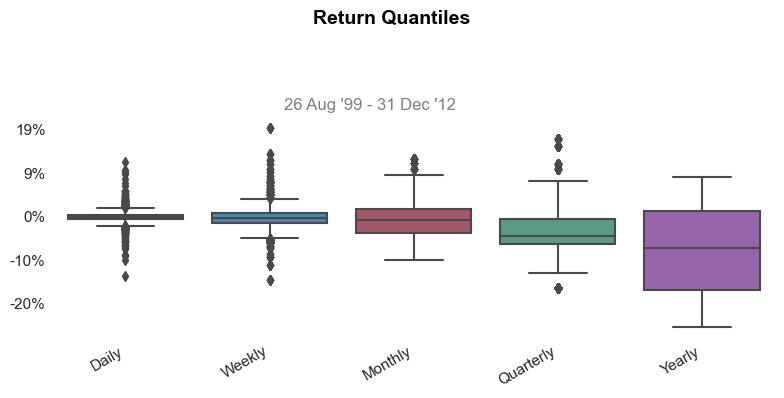

In [43]:
qs.reports.full(remove_timezone(equity_curve), remove_timezone(benchmark))

# Feature Select for Technical Analysis Features

In [44]:
drop_cols = ["open", "high", "low", "close", "volume"]
Xdf = technical_features.drop(drop_cols, axis=1)
cprint(Xdf)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                           fwd_8     volume_adi  volume_obv  volume_cmf  \
Date                                                                      
1999-04-07 00:00:00-04:00   -1.0   65729.629692     1484460   -0.017156   
1999-04-09 00:00:00-04:00   -1.0  108919.389847     1635627   -0.029240   
1999-04-12 00:00:00-04:00   -1.0  285064.597027     1829386    0.026873   
1999-04-13 00:00:00-04:00   -1.0  140014.872272     1619870   -0.016284   
1999-04-14 00:00:00-04:00   -1.0  -20631.127728     1459224   -0.068971   

                              volume_fi  volume_em  volume_sma_em  \
Date                                                                
1999-04-07 00:00:00-04:00  12571.865578  16.324091       9.207207   
1999-04-09 00:00:00-04:00  15197.170736  37.899711       9.926184   

In [45]:
FEAT_COLS = [x for x in Xdf.columns if "fwd" not in x]
X, y = create_Xy(Xdf, FEAT_COLS, Y_TARGET_COL)

cprint(X)
cprint(y)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                              volume_adi  volume_obv  volume_cmf  \
Date                                                               
1999-04-07 00:00:00-04:00   65729.629692     1484460   -0.017156   
1999-04-09 00:00:00-04:00  108919.389847     1635627   -0.029240   
1999-04-12 00:00:00-04:00  285064.597027     1829386    0.026873   
1999-04-13 00:00:00-04:00  140014.872272     1619870   -0.016284   
1999-04-14 00:00:00-04:00  -20631.127728     1459224   -0.068971   

                              volume_fi  volume_em  volume_sma_em  \
Date                                                                
1999-04-07 00:00:00-04:00  12571.865578  16.324091       9.207207   
1999-04-09 00:00:00-04:00  15197.170736  37.899711       9.926184   
1999-04-12 00:00:00-04:00  19564.692159  19.7108

In [46]:
# normalize


def roll_zscore(x, window):
    r = x.rolling(window=window)
    m = r.mean().shift(1)
    s = r.std(ddof=0).shift(1)
    z = (x - m) / s
    return z


X_scaled = roll_zscore(X, window=WINDOW)
X_scaled = X_scaled[np.isfinite(X_scaled)].dropna()
cprint(X_scaled)

# match index
y = y.loc[X_scaled.index]
cprint(y)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                           volume_adi  volume_obv  volume_cmf  volume_fi  \
Date                                                                       
1999-05-25 00:00:00-04:00   -1.764883   -2.615844    0.407667  -2.500612   
1999-05-26 00:00:00-04:00    0.533827   -1.509675    1.733704  -0.756847   
1999-05-27 00:00:00-04:00    0.321776   -1.574238    1.665560  -0.746536   
1999-05-28 00:00:00-04:00    0.757964   -1.307511    1.792265  -0.419494   
1999-06-01 00:00:00-04:00    0.501555   -2.021230    0.467431  -0.826566   

                           volume_em  volume_sma_em  volume_vpt  volume_vwap  \
Date                                                                           
1999-05-25 00:00:00-04:00  -1.577094      -1.909821   -2.410390    -1.527903   
1999-05-26 00:00:00-04:00   

In [47]:
from BorutaShap import BorutaShap

In [48]:
# no model selected default is Random Forest, if classification is False it is a Regression problem
Feature_Selector = BorutaShap(importance_measure="shap", classification=True)

Feature_Selector.fit(X=X_scaled, y=y.values, n_trials=25, random_state=0)

  0%|          | 0/25 [00:00<?, ?it/s]

2 attributes confirmed important: ['momentum_uo', 'volume_cmf']
59 attributes confirmed unimportant: ['volatility_kcc', 'trend_stc', 'trend_adx_neg', 'volatility_bbp', 'volatility_kcli', 'trend_sma_fast', 'momentum_ppo', 'momentum_stoch_rsi_d', 'volatility_bbhi', 'volatility_bbm', 'volume_vpt', 'momentum_rsi', 'momentum_stoch_rsi', 'trend_aroon_ind', 'others_dr', 'trend_vortex_ind_diff', 'trend_dpo', 'volume_sma_em', 'volatility_kch', 'volume_vwap', 'momentum_kama', 'trend_adx_pos', 'volatility_bbli', 'trend_mass_index', 'volume_nvi', 'momentum_pvo', 'momentum_ppo_signal', 'trend_macd_signal', 'volatility_bbw', 'volatility_atr', 'trend_aroon_down', 'trend_vortex_ind_pos', 'volatility_dcw', 'trend_cci', 'momentum_stoch_rsi_k', 'others_dlr', 'momentum_ao', 'momentum_roc', 'trend_ichimoku_a', 'volatility_bbl', 'trend_psar_down_indicator', 'volatility_kcw', 'trend_ichimoku_conv', 'trend_ichimoku_base', 'volume_obv', 'trend_aroon_up', 'volatility_dcm', 'volume_fi', 'trend_visual_ichimoku_a'

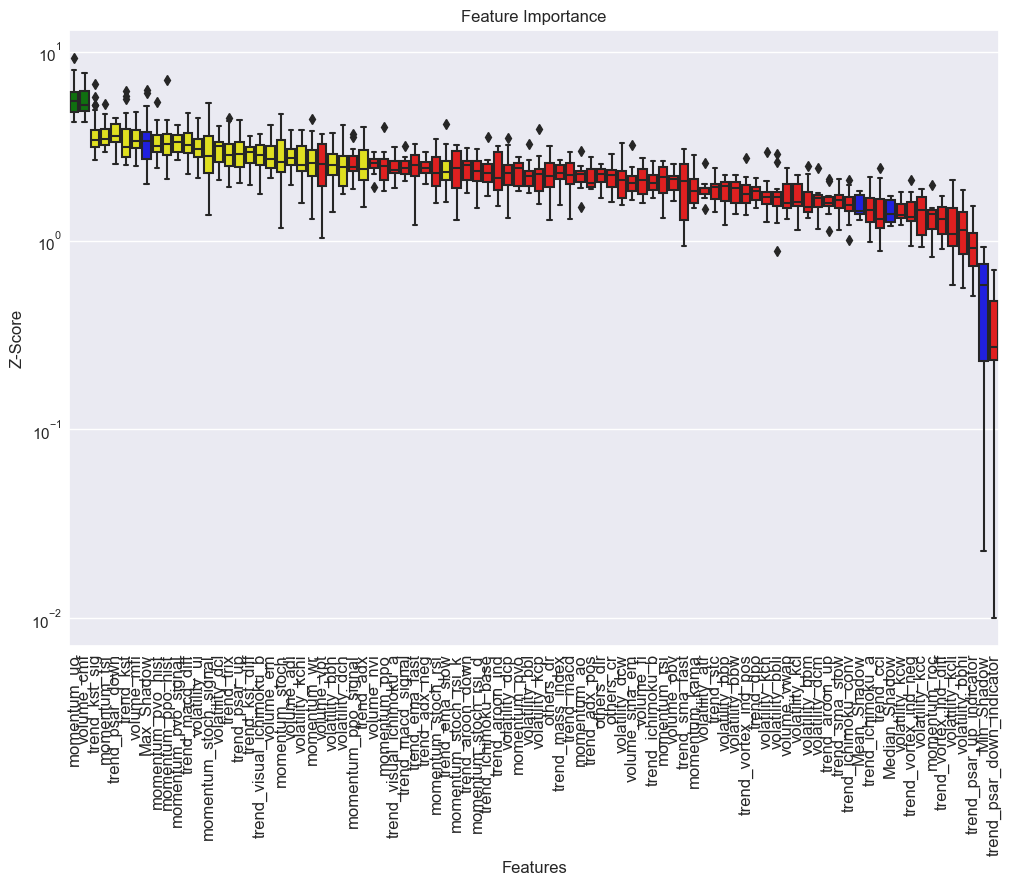

In [49]:
Feature_Selector.plot(X_size=12, figsize=(12, 8), y_scale="log", which_features="all")

In [50]:
Feature_Selector.TentativeRoughFix()

3 tentative features are now accepted: ['trend_kst_sig' 'momentum_tsi' 'trend_psar_down']
22 tentative features are now rejected: ['volatility_bbh' 'volume_adi' 'trend_ema_slow' 'volatility_kchi'
 'momentum_stoch_signal' 'volatility_dcl' 'momentum_pvo_hist'
 'momentum_wr' 'momentum_stoch' 'trend_kst_diff' 'volatility_dch'
 'volume_em' 'trend_psar_up' 'volume_mfi' 'volatility_ui' 'trend_adx'
 'trend_macd_diff' 'trend_visual_ichimoku_b' 'momentum_pvo_signal'
 'trend_trix' 'trend_kst' 'momentum_ppo_hist']


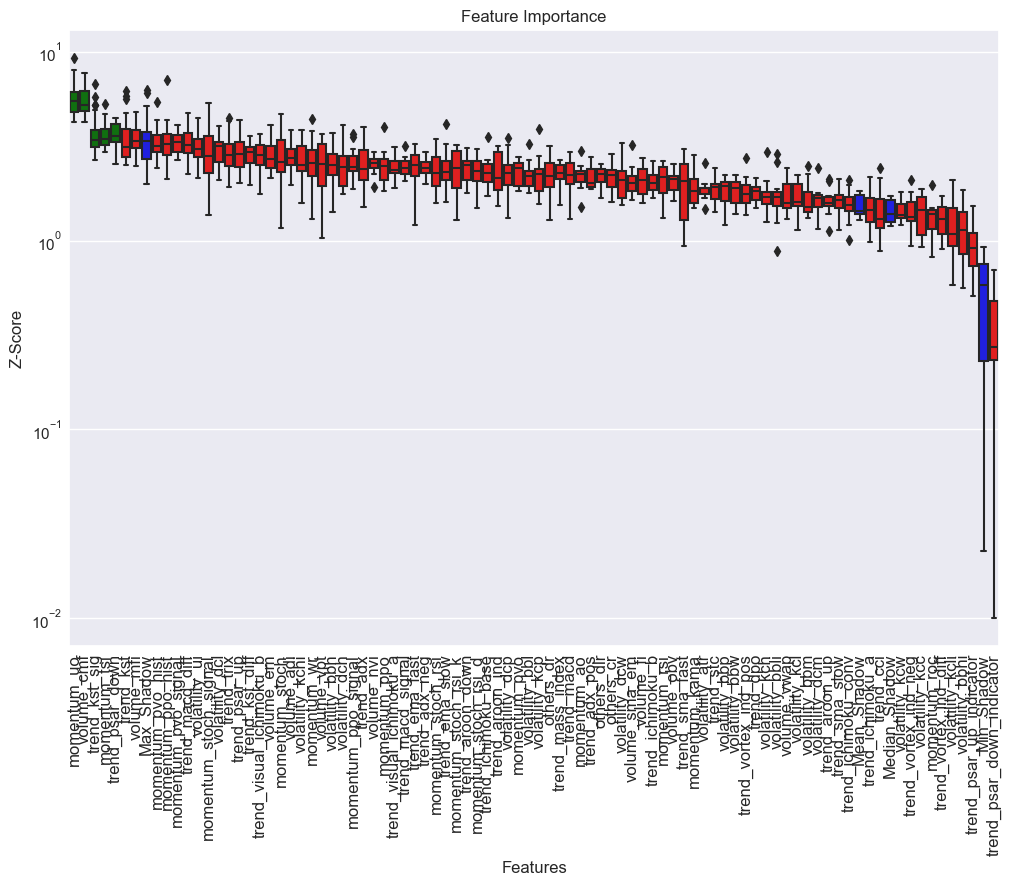

In [51]:
Feature_Selector.plot(X_size=12, figsize=(12, 8), y_scale="log", which_features="all")

In [52]:
Feature_Selector.results_to_csv(filename="borutashap_feature_importance")

In [53]:
Feature_Selector.tentative

array(['volatility_bbh', 'volume_adi', 'trend_ema_slow', 'trend_kst_sig',
       'volatility_kchi', 'momentum_stoch_signal', 'volatility_dcl',
       'momentum_wr', 'momentum_stoch', 'volatility_dch', 'volume_em',
       'trend_psar_up', 'trend_adx', 'trend_macd_diff',
       'trend_visual_ichimoku_b', 'momentum_pvo_signal', 'trend_trix',
       'trend_kst', 'momentum_pvo_hist', 'momentum_tsi', 'trend_kst_diff',
       'volume_mfi', 'volatility_ui', 'trend_psar_down',
       'momentum_ppo_hist'], dtype='<U23')

In [54]:
dir(Feature_Selector)

['Check_if_chose_train_or_test_and_train_model',
 'Shadow_feature_import',
 'Subset',
 'TentativeRoughFix',
 'Train_model',
 'X',
 'X_boruta',
 'X_boruta_test',
 'X_boruta_train',
 'X_categorical',
 'X_feature_import',
 'X_shadow',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'accepted',
 'accepted_columns',
 'all_columns',
 'average_of_list',
 'binomial_H0_test',
 'bonferoni_corrections',
 'box_plot',
 'calculate_Zscore',
 'calculate_hits',
 'calculate_rejected_accepted_tentative',
 'check_X',
 'check_if_which_features_is_correct',
 'check_missing_values',
 'check_model',
 'classification',
 'columns',
 'create_importance_history',
 'create_list',
 'create_mapping_

## use selected features only

In [55]:
selected_features = Feature_Selector.accepted
selected_features

['momentum_uo',
 'volume_cmf',
 'trend_kst_sig',
 'momentum_tsi',
 'trend_psar_down']

In [56]:
X, y = create_Xy(Xdf, selected_features, Y_TARGET_COL)
cprint(X)
cprint(y)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                           momentum_uo  volume_cmf  trend_kst_sig  \
Date                                                                
1999-04-07 00:00:00-04:00    56.652900   -0.017156      59.028350   
1999-04-09 00:00:00-04:00    54.084918   -0.029240      55.322779   
1999-04-12 00:00:00-04:00    61.757183    0.026873      52.387806   
1999-04-13 00:00:00-04:00    62.357713   -0.016284      50.099614   
1999-04-14 00:00:00-04:00    55.013268   -0.068971      48.070895   

                           momentum_tsi  trend_psar_down  
Date                                                      
1999-04-07 00:00:00-04:00     11.748637        12.908725  
1999-04-09 00:00:00-04:00     14.274639        12.908725  
1999-04-12 00:00:00-04:00     17.530935        12.908725  
1999-04-13 00:00:00-04

## run walkforward test

In [57]:
scores, predictions = walkforward_with_purging_and_embargos(
    model=create_model(),
    X=X,
    y=y,
    purged_window_size=0,
    embargo_period=2,
    lookback=100,
    test_size=10,
    scaler=StandardScaler(),
    scorer=matthews_corrcoef,
)

*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-09-23 00:00:00-04:00
test index:: start: 1999-09-24 00:00:00-04:00 end: 1999-10-07 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-09-21 00:00:00-04:00
test index:: start: 1999-09-24 00:00:00-04:00 end: 1999-10-07 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-10-07 00:00:00-04:00
test index:: start: 1999-10-08 00:00:00-04:00 end: 1999-10-21 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-10-05 00:00:00-04:00
test index:: start: 1999-10-08 00:00:00-04:00 end: 1999-10-21 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-10-21 00:00:00-04:00
test index:: start: 1999-1

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-06-21 00:00:00-04:00
test index:: start: 2000-06-26 00:00:00-04:00 end: 2000-07-10 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-07-10 00:00:00-04:00
test index:: start: 2000-07-11 00:00:00-04:00 end: 2000-07-24 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-07-06 00:00:00-04:00
test index:: start: 2000-07-11 00:00:00-04:00 end: 2000-07-24 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-07-24 00:00:00-04:00
test index:: start: 2000-07-25 00:00:00-04:00 end: 2000-08-07 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-07-20 00:00:00-04:00
test index:: start: 2000-07-25 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-04-06 00:00:00-04:00
test index:: start: 2001-04-11 00:00:00-04:00 end: 2001-04-25 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-04-25 00:00:00-04:00
test index:: start: 2001-04-26 00:00:00-04:00 end: 2001-05-09 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-04-23 00:00:00-04:00
test index:: start: 2001-04-26 00:00:00-04:00 end: 2001-05-09 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-05-09 00:00:00-04:00
test index:: start: 2001-05-10 00:00:00-04:00 end: 2001-05-24 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-05-07 00:00:00-04:00
test index:: start: 2001-05-10 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-01-30 00:00:00-05:00
test index:: start: 2002-02-04 00:00:00-05:00 end: 2002-02-15 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-02-15 00:00:00-05:00
test index:: start: 2002-02-19 00:00:00-05:00 end: 2002-03-04 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-02-13 00:00:00-05:00
test index:: start: 2002-02-19 00:00:00-05:00 end: 2002-03-04 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-03-04 00:00:00-05:00
test index:: start: 2002-03-05 00:00:00-05:00 end: 2002-03-18 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-02-28 00:00:00-05:00
test index:: start: 2002-03-05 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-11-13 00:00:00-05:00
test index:: start: 2002-11-18 00:00:00-05:00 end: 2002-12-02 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-12-02 00:00:00-05:00
test index:: start: 2002-12-03 00:00:00-05:00 end: 2002-12-16 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-11-27 00:00:00-05:00
test index:: start: 2002-12-03 00:00:00-05:00 end: 2002-12-16 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-12-16 00:00:00-05:00
test index:: start: 2002-12-17 00:00:00-05:00 end: 2002-12-31 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-12-12 00:00:00-05:00
test index:: start: 2002-12-17 0

...

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-04-09 00:00:00-04:00
test index:: start: 2009-04-15 00:00:00-04:00 end: 2009-04-28 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-04-28 00:00:00-04:00
test index:: start: 2009-04-29 00:00:00-04:00 end: 2009-05-12 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-04-24 00:00:00-04:00
test index:: start: 2009-04-29 00:00:00-04:00 end: 2009-05-12 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-05-12 00:00:00-04:00
test index:: start: 2009-05-13 00:00:00-04:00 end: 2009-05-27 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-05-08 00:00:00-04:00
test index:: start: 2009-05-13 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-01-26 00:00:00-05:00
test index:: start: 2010-01-29 00:00:00-05:00 end: 2010-02-11 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-02-11 00:00:00-05:00
test index:: start: 2010-02-12 00:00:00-05:00 end: 2010-02-26 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-02-09 00:00:00-05:00
test index:: start: 2010-02-12 00:00:00-05:00 end: 2010-02-26 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-02-26 00:00:00-05:00
test index:: start: 2010-03-01 00:00:00-05:00 end: 2010-03-12 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-02-24 00:00:00-05:00
test index:: start: 2010-03-01 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-11-09 00:00:00-05:00
test index:: start: 2010-11-12 00:00:00-05:00 end: 2010-11-26 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-11-26 00:00:00-05:00
test index:: start: 2010-11-29 00:00:00-05:00 end: 2010-12-10 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-11-23 00:00:00-05:00
test index:: start: 2010-11-29 00:00:00-05:00 end: 2010-12-10 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-12-10 00:00:00-05:00
test index:: start: 2010-12-13 00:00:00-05:00 end: 2010-12-27 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-12-08 00:00:00-05:00
test index:: start: 2010-12-13 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-08-29 00:00:00-04:00
test index:: start: 2011-09-01 00:00:00-04:00 end: 2011-09-15 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-09-15 00:00:00-04:00
test index:: start: 2011-09-16 00:00:00-04:00 end: 2011-09-29 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-09-13 00:00:00-04:00
test index:: start: 2011-09-16 00:00:00-04:00 end: 2011-09-29 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-09-29 00:00:00-04:00
test index:: start: 2011-09-30 00:00:00-04:00 end: 2011-10-13 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-09-27 00:00:00-04:00
test index:: start: 2011-09-30 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-06-15 00:00:00-04:00
test index:: start: 2012-06-20 00:00:00-04:00 end: 2012-07-03 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-07-03 00:00:00-04:00
test index:: start: 2012-07-05 00:00:00-04:00 end: 2012-07-19 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-06-29 00:00:00-04:00
test index:: start: 2012-07-05 00:00:00-04:00 end: 2012-07-19 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-07-19 00:00:00-04:00
test index:: start: 2012-07-20 00:00:00-04:00 end: 2012-08-02 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-07-16 00:00:00-04:00
test index:: start: 2012-07-20 0

## evaluate results

In [58]:
# evaluate results
STARTING_VALUE = 100
equity_curve, equity_returns = get_estimated_backtests(
    predictions, actual_returns, starting_value=STARTING_VALUE
)
benchmark = returns_to_index(
    actual_returns.loc[equity_curve.index], starting_value=STARTING_VALUE
)

In [59]:
update_agg_results(
    hdf_store_fp, "selected_features_model", scores, equity_curve, equity_returns
)

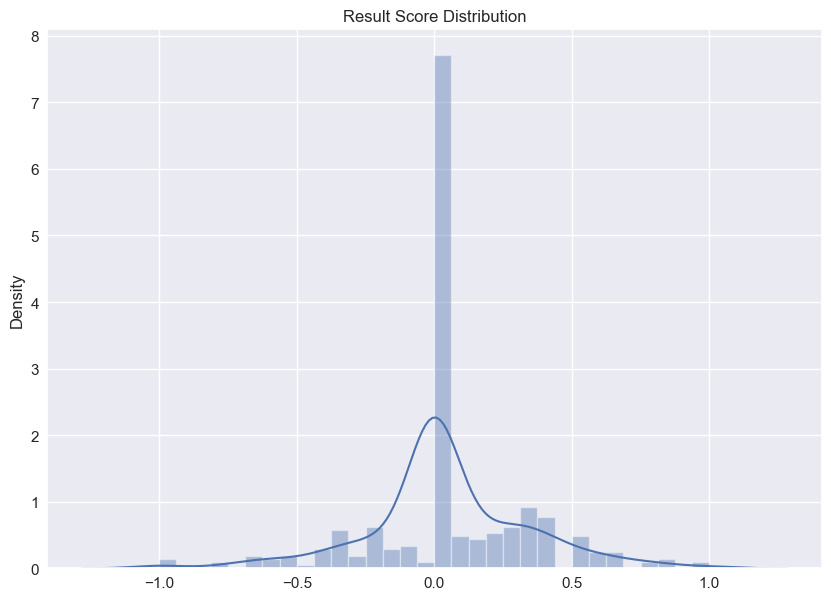

<AxesSubplot: xlabel='Date'>

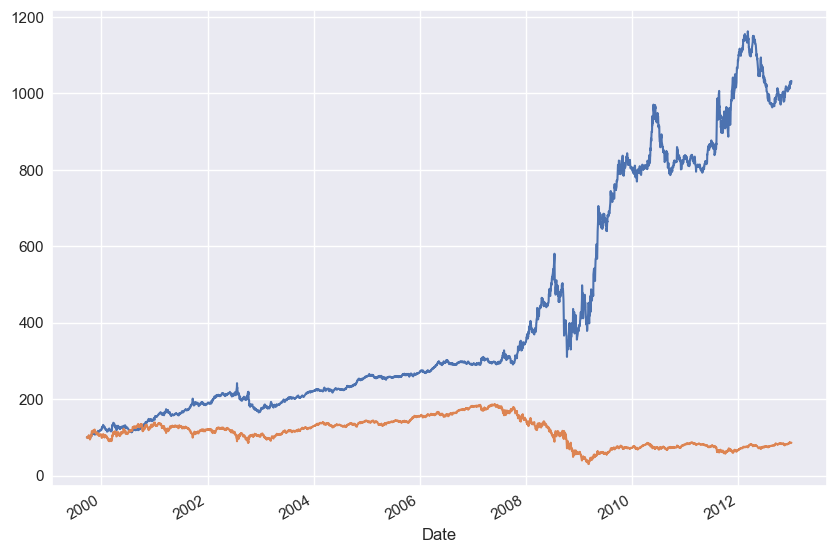

In [60]:
plot_scores(scores)
pd.Series(scores).describe()

equity_curve.plot()
benchmark.plot()

                           Strategy    Benchmark
-------------------------  ----------  -----------
Start Period               1999-09-24  1999-09-24
End Period                 2012-12-31  2012-12-31
Risk-Free Rate             0.0%        0.0%
Time in Market             99.0%       99.0%

Cumulative Return          927.0%      -14.46%
CAGR﹪                     19.17%      -1.17%

Sharpe                     0.89        0.14
Prob. Sharpe Ratio         99.93%      69.15%
Smart Sharpe               0.85        0.13
Sortino                    1.29        0.2
Smart Sortino              1.24        0.19
Sortino/√2                 0.91        0.14
Smart Sortino/√2           0.88        0.14
Omega                      1.2         1.2

Max Drawdown               -46.5%      -83.71%
Longest DD Days            818         2037
Volatility (ann.)          22.88%      34.49%
R^2                        0.02        0.02
Information Ratio          0.02        0.02
Calmar                     0.41        

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2008-07-16,2008-10-09,2009-04-28,286,-46.499366,-43.197061
2,2002-07-24,2002-12-19,2004-10-19,818,-31.668778,-30.515033
3,2010-05-28,2010-09-20,2011-08-08,437,-18.995591,-18.424383
4,2000-03-27,2000-07-28,2000-10-30,217,-18.152634,-16.946562
5,2012-03-07,2012-08-21,2012-12-31,299,-17.125569,-16.839364


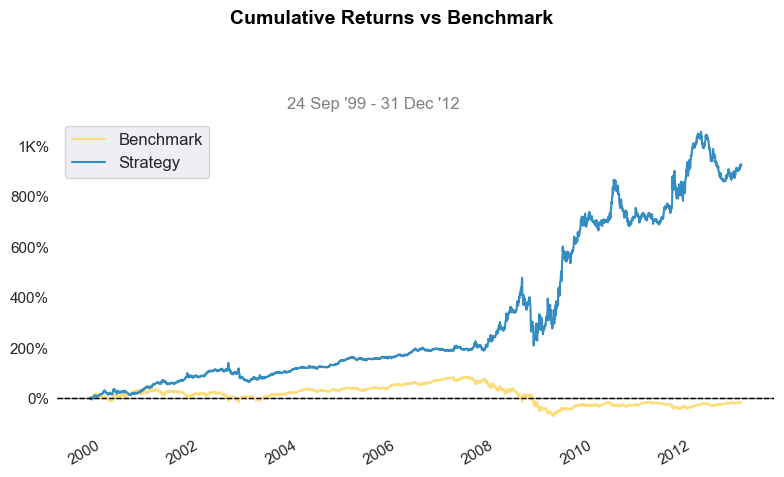

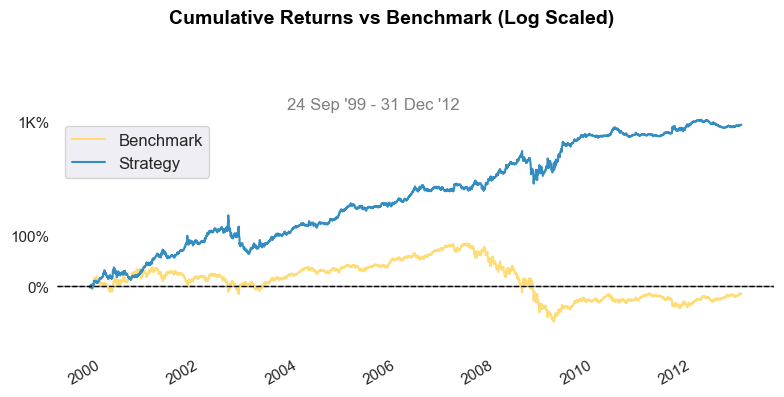

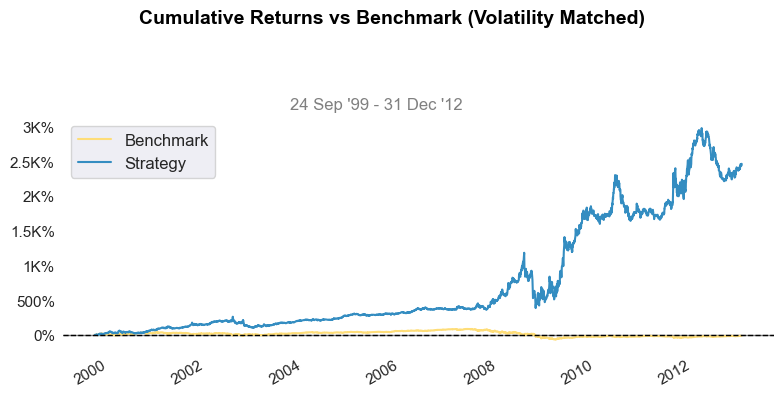

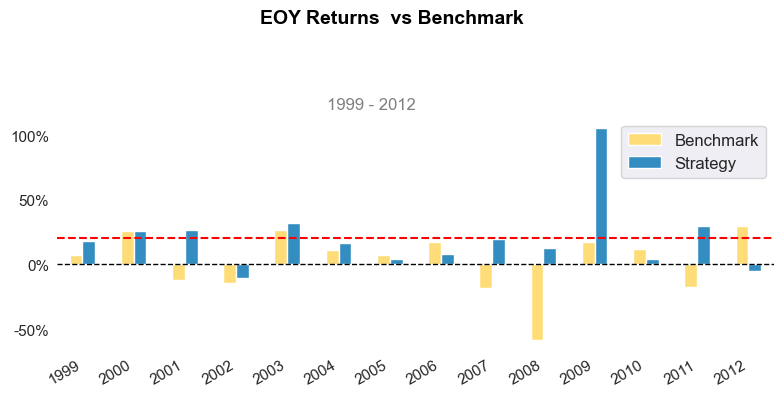

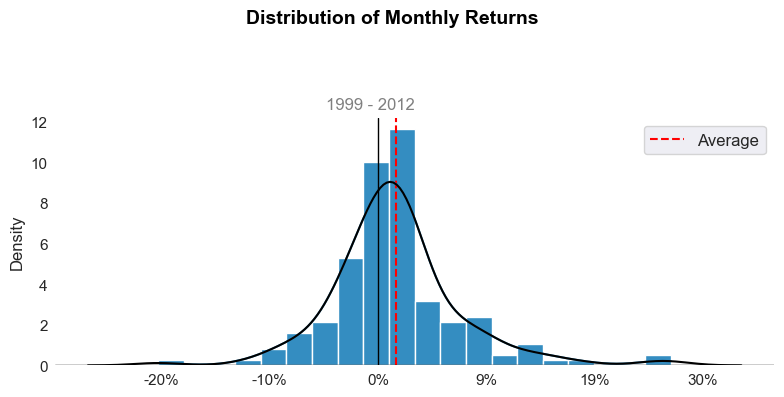

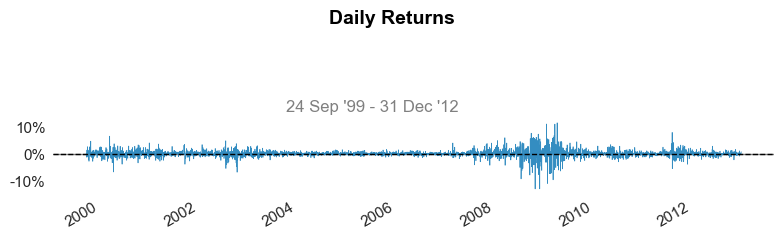

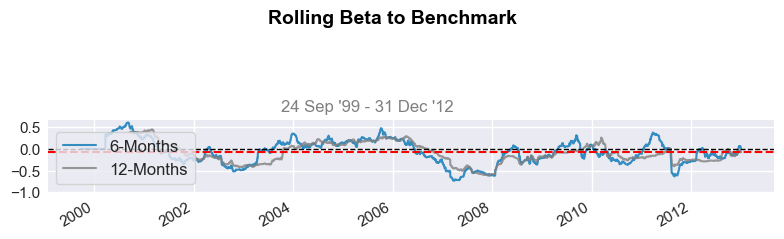

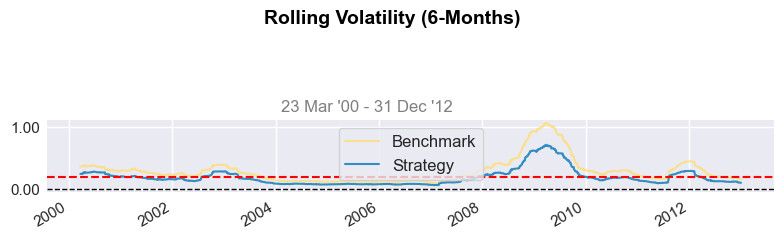

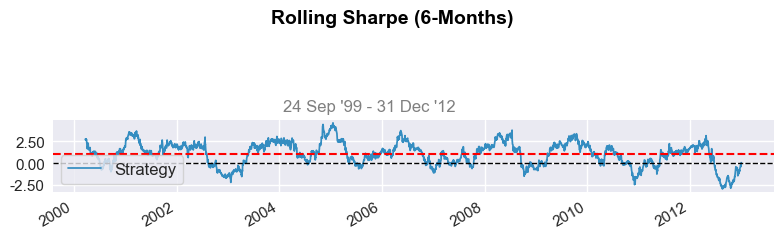

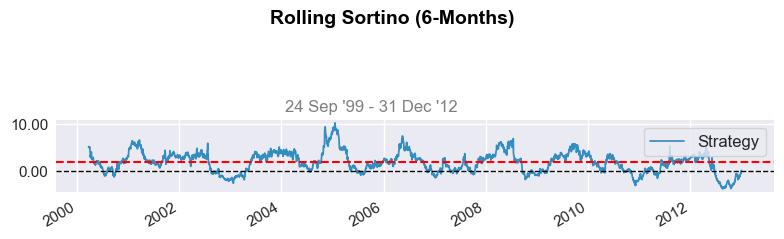

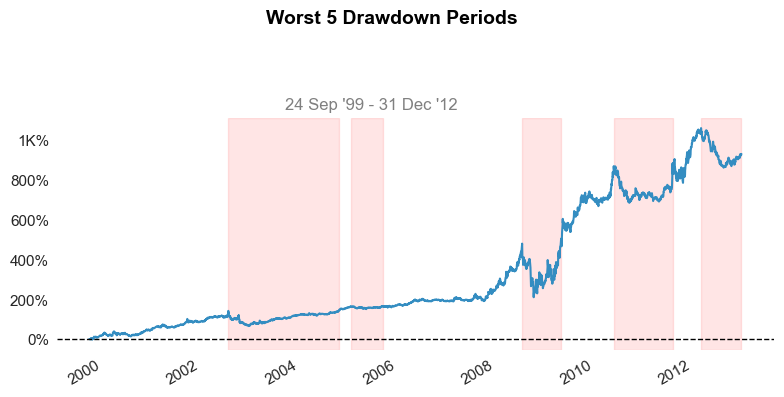

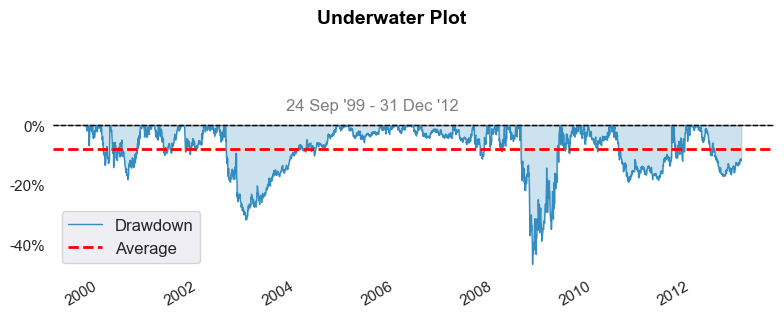

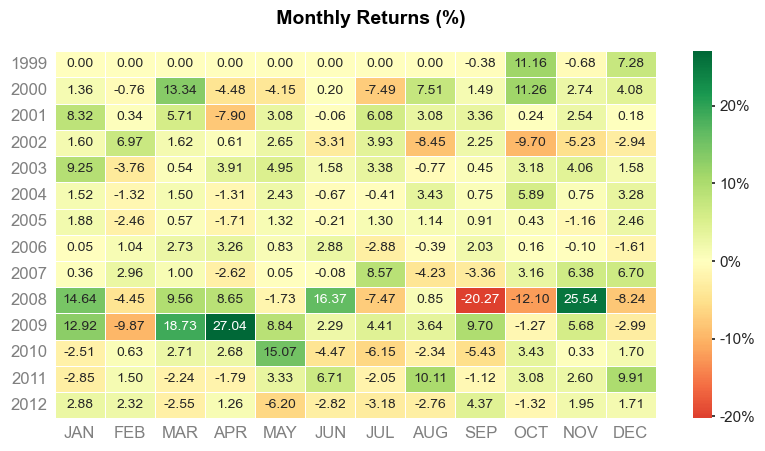

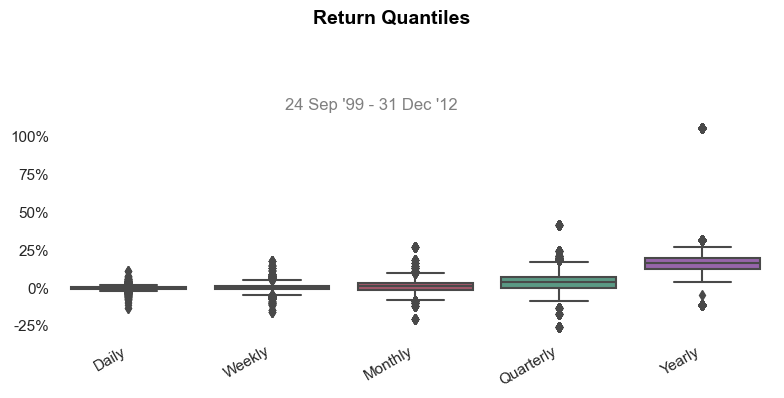

In [61]:
qs.reports.full(remove_timezone(equity_curve), remove_timezone(benchmark))

## let's attempt with tentative and selected

In [62]:
Feature_Selector.tentative

array(['volatility_bbh', 'volume_adi', 'trend_ema_slow', 'trend_kst_sig',
       'volatility_kchi', 'momentum_stoch_signal', 'volatility_dcl',
       'momentum_wr', 'momentum_stoch', 'volatility_dch', 'volume_em',
       'trend_psar_up', 'trend_adx', 'trend_macd_diff',
       'trend_visual_ichimoku_b', 'momentum_pvo_signal', 'trend_trix',
       'trend_kst', 'momentum_pvo_hist', 'momentum_tsi', 'trend_kst_diff',
       'volume_mfi', 'volatility_ui', 'trend_psar_down',
       'momentum_ppo_hist'], dtype='<U23')

In [63]:
selected_features = set(
    list(Feature_Selector.tentative) + list(Feature_Selector.accepted)
)
selected_features

{'momentum_ppo_hist',
 'momentum_pvo_hist',
 'momentum_pvo_signal',
 'momentum_stoch',
 'momentum_stoch_signal',
 'momentum_tsi',
 'momentum_uo',
 'momentum_wr',
 'trend_adx',
 'trend_ema_slow',
 'trend_kst',
 'trend_kst_diff',
 'trend_kst_sig',
 'trend_macd_diff',
 'trend_psar_down',
 'trend_psar_up',
 'trend_trix',
 'trend_visual_ichimoku_b',
 'volatility_bbh',
 'volatility_dch',
 'volatility_dcl',
 'volatility_kchi',
 'volatility_ui',
 'volume_adi',
 'volume_cmf',
 'volume_em',
 'volume_mfi'}

In [64]:
X, y = create_Xy(Xdf, selected_features, Y_TARGET_COL)
cprint(X)
cprint(y)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                           volatility_bbh     volume_adi  trend_ema_slow  \
Date                                                                       
1999-04-07 00:00:00-04:00       13.237311   65729.629692       12.642597   
1999-04-09 00:00:00-04:00       13.301452  108919.389847       12.691840   
1999-04-12 00:00:00-04:00       13.414783  285064.597027       12.754933   
1999-04-13 00:00:00-04:00       13.505440  140014.872272       12.812186   
1999-04-14 00:00:00-04:00       13.545398  -20631.127728       12.852366   

                           trend_kst_sig  volatility_kchi  \
Date                                                        
1999-04-07 00:00:00-04:00      59.028350              1.0   
1999-04-09 00:00:00-04:00      55.322779              1.0   
1999-04-12 00:00:00-04:0

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3438 entries, 1999-04-07 00:00:00-04:00 to 2012-12-31 00:00:00-05:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   fwd_8   3438 non-null   float64
dtypes: float64(1)
memory usage: 182.8 KB
None
*******************************************************************************



## run walkforward

In [65]:
scores, predictions = walkforward_with_purging_and_embargos(
    model=create_model(),
    X=X,
    y=y,
    purged_window_size=0,
    embargo_period=2,
    lookback=100,
    test_size=10,
    scaler=StandardScaler(),
    scorer=matthews_corrcoef,
)

*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-09-23 00:00:00-04:00
test index:: start: 1999-09-24 00:00:00-04:00 end: 1999-10-07 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-09-21 00:00:00-04:00
test index:: start: 1999-09-24 00:00:00-04:00 end: 1999-10-07 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-10-07 00:00:00-04:00
test index:: start: 1999-10-08 00:00:00-04:00 end: 1999-10-21 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-10-05 00:00:00-04:00
test index:: start: 1999-10-08 00:00:00-04:00 end: 1999-10-21 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 1999-10-21 00:00:00-04:00
test index:: start: 1999-1

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-06-21 00:00:00-04:00
test index:: start: 2000-06-26 00:00:00-04:00 end: 2000-07-10 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-07-10 00:00:00-04:00
test index:: start: 2000-07-11 00:00:00-04:00 end: 2000-07-24 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-07-06 00:00:00-04:00
test index:: start: 2000-07-11 00:00:00-04:00 end: 2000-07-24 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-07-24 00:00:00-04:00
test index:: start: 2000-07-25 00:00:00-04:00 end: 2000-08-07 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2000-07-20 00:00:00-04:00
test index:: start: 2000-07-25 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-04-06 00:00:00-04:00
test index:: start: 2001-04-11 00:00:00-04:00 end: 2001-04-25 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-04-25 00:00:00-04:00
test index:: start: 2001-04-26 00:00:00-04:00 end: 2001-05-09 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-04-23 00:00:00-04:00
test index:: start: 2001-04-26 00:00:00-04:00 end: 2001-05-09 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-05-09 00:00:00-04:00
test index:: start: 2001-05-10 00:00:00-04:00 end: 2001-05-24 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2001-05-07 00:00:00-04:00
test index:: start: 2001-05-10 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-01-30 00:00:00-05:00
test index:: start: 2002-02-04 00:00:00-05:00 end: 2002-02-15 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-02-15 00:00:00-05:00
test index:: start: 2002-02-19 00:00:00-05:00 end: 2002-03-04 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-02-13 00:00:00-05:00
test index:: start: 2002-02-19 00:00:00-05:00 end: 2002-03-04 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-03-04 00:00:00-05:00
test index:: start: 2002-03-05 00:00:00-05:00 end: 2002-03-18 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-02-28 00:00:00-05:00
test index:: start: 2002-03-05 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-11-13 00:00:00-05:00
test index:: start: 2002-11-18 00:00:00-05:00 end: 2002-12-02 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-12-02 00:00:00-05:00
test index:: start: 2002-12-03 00:00:00-05:00 end: 2002-12-16 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-11-27 00:00:00-05:00
test index:: start: 2002-12-03 00:00:00-05:00 end: 2002-12-16 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-12-16 00:00:00-05:00
test index:: start: 2002-12-17 00:00:00-05:00 end: 2002-12-31 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2002-12-12 00:00:00-05:00
test index:: start: 2002-12-17 0

...

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-04-09 00:00:00-04:00
test index:: start: 2009-04-15 00:00:00-04:00 end: 2009-04-28 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-04-28 00:00:00-04:00
test index:: start: 2009-04-29 00:00:00-04:00 end: 2009-05-12 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-04-24 00:00:00-04:00
test index:: start: 2009-04-29 00:00:00-04:00 end: 2009-05-12 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-05-12 00:00:00-04:00
test index:: start: 2009-05-13 00:00:00-04:00 end: 2009-05-27 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2009-05-08 00:00:00-04:00
test index:: start: 2009-05-13 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-01-26 00:00:00-05:00
test index:: start: 2010-01-29 00:00:00-05:00 end: 2010-02-11 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-02-11 00:00:00-05:00
test index:: start: 2010-02-12 00:00:00-05:00 end: 2010-02-26 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-02-09 00:00:00-05:00
test index:: start: 2010-02-12 00:00:00-05:00 end: 2010-02-26 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-02-26 00:00:00-05:00
test index:: start: 2010-03-01 00:00:00-05:00 end: 2010-03-12 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-02-24 00:00:00-05:00
test index:: start: 2010-03-01 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-11-09 00:00:00-05:00
test index:: start: 2010-11-12 00:00:00-05:00 end: 2010-11-26 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-11-26 00:00:00-05:00
test index:: start: 2010-11-29 00:00:00-05:00 end: 2010-12-10 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-11-23 00:00:00-05:00
test index:: start: 2010-11-29 00:00:00-05:00 end: 2010-12-10 00:00:00-05:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-12-10 00:00:00-05:00
test index:: start: 2010-12-13 00:00:00-05:00 end: 2010-12-27 00:00:00-05:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2010-12-08 00:00:00-05:00
test index:: start: 2010-12-13 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-08-29 00:00:00-04:00
test index:: start: 2011-09-01 00:00:00-04:00 end: 2011-09-15 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-09-15 00:00:00-04:00
test index:: start: 2011-09-16 00:00:00-04:00 end: 2011-09-29 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-09-13 00:00:00-04:00
test index:: start: 2011-09-16 00:00:00-04:00 end: 2011-09-29 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-09-29 00:00:00-04:00
test index:: start: 2011-09-30 00:00:00-04:00 end: 2011-10-13 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2011-09-27 00:00:00-04:00
test index:: start: 2011-09-30 0

----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-06-15 00:00:00-04:00
test index:: start: 2012-06-20 00:00:00-04:00 end: 2012-07-03 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-07-03 00:00:00-04:00
test index:: start: 2012-07-05 00:00:00-04:00 end: 2012-07-19 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-06-29 00:00:00-04:00
test index:: start: 2012-07-05 00:00:00-04:00 end: 2012-07-19 00:00:00-04:00


*******************************************************
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-07-19 00:00:00-04:00
test index:: start: 2012-07-20 00:00:00-04:00 end: 2012-08-02 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 1999-04-07 00:00:00-04:00 end: 2012-07-16 00:00:00-04:00
test index:: start: 2012-07-20 0

## Evaluate Results

In [66]:
# evaluate results
STARTING_VALUE = 100
equity_curve, equity_returns = get_estimated_backtests(
    predictions, actual_returns, starting_value=STARTING_VALUE
)
benchmark = returns_to_index(
    actual_returns.loc[equity_curve.index], starting_value=STARTING_VALUE
)

In [67]:
update_agg_results(
    hdf_store_fp,
    "selected_and_tentative_features_model",
    scores,
    equity_curve,
    equity_returns,
)

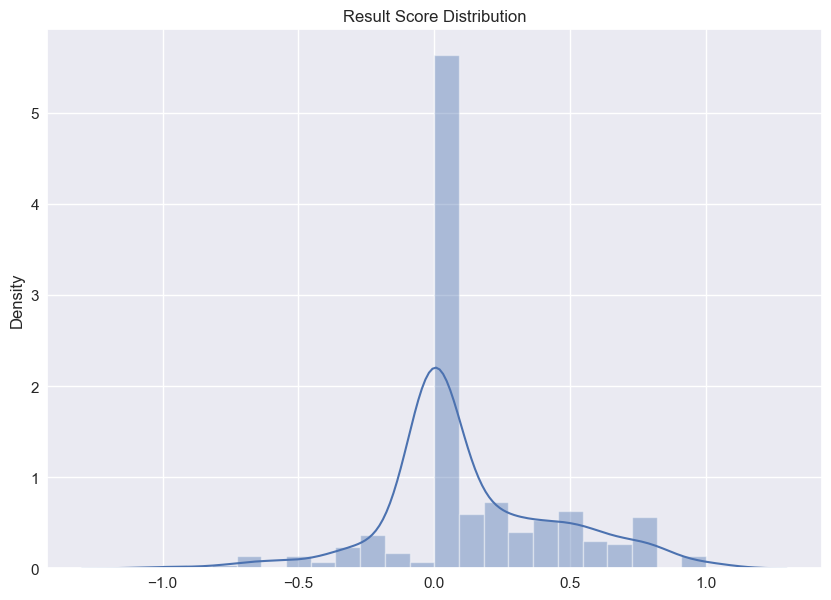

<AxesSubplot: xlabel='Date'>

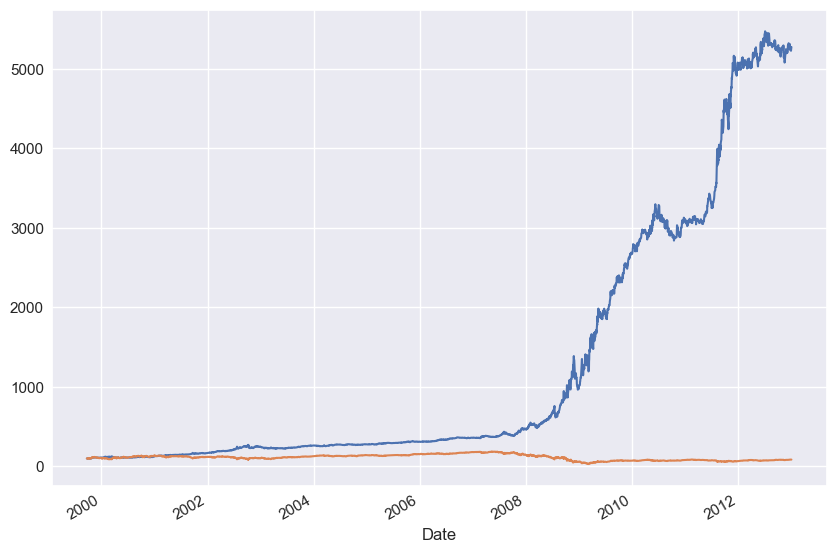

In [68]:
plot_scores(scores)
pd.Series(scores).describe()

equity_curve.plot()
benchmark.plot()

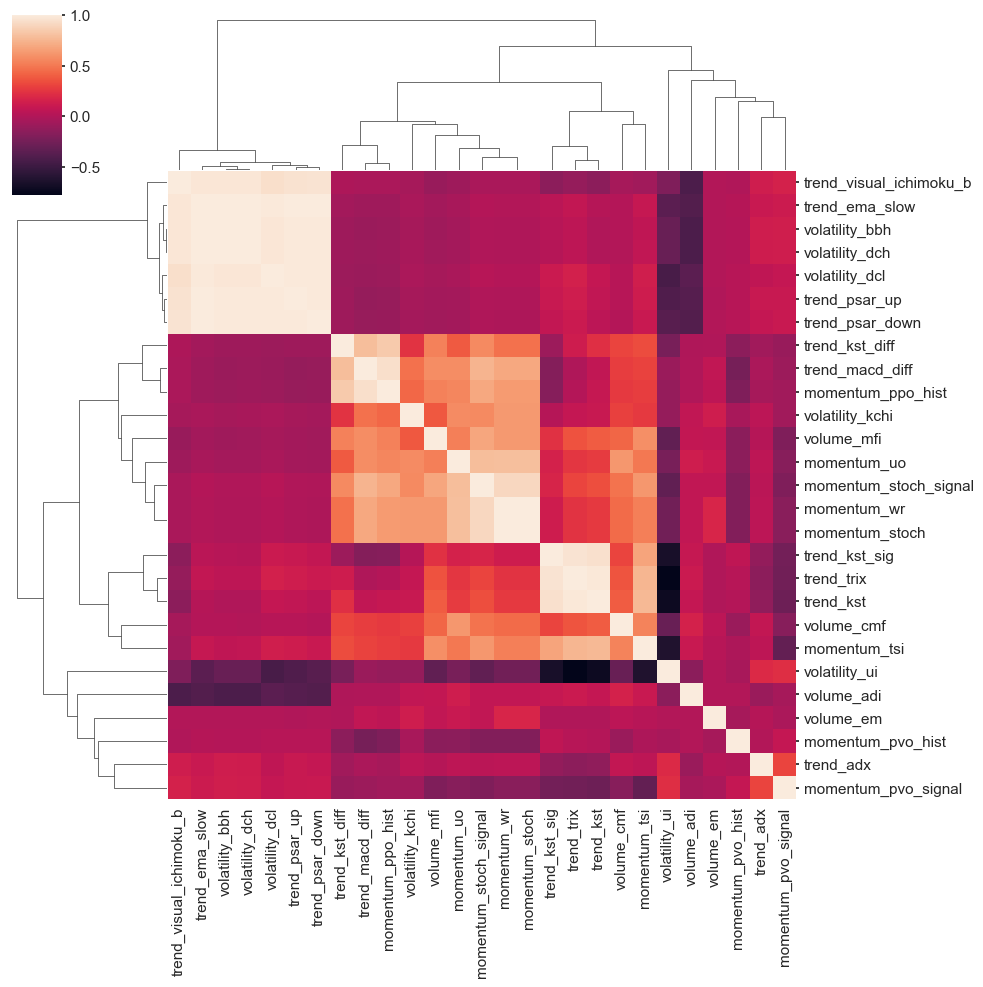

In [69]:
sns.clustermap(Xdf[selected_features].corr())

                           Strategy    Benchmark
-------------------------  ----------  -----------
Start Period               1999-09-24  1999-09-24
End Period                 2012-12-31  2012-12-31
Risk-Free Rate             0.0%        0.0%
Time in Market             99.0%       99.0%

Cumulative Return          5,138.70%   -14.46%
CAGR﹪                     34.73%      -1.17%

Sharpe                     1.51        0.14
Prob. Sharpe Ratio         100.0%      69.15%
Smart Sharpe               1.45        0.13
Sortino                    2.39        0.2
Smart Sortino              2.3         0.19
Sortino/√2                 1.69        0.14
Smart Sortino/√2           1.62        0.14
Omega                      1.36        1.36

Max Drawdown               -30.45%     -83.71%
Longest DD Days            571         2037
Volatility (ann.)          21.44%      34.49%
R^2                        0.03        0.03
Information Ratio          0.04        0.04
Calmar                     1.14       

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2008-11-26,2008-12-23,2009-02-11,77,-30.448487,-29.771600
2,2008-07-16,2008-07-22,2008-08-25,40,-18.915047,-18.845821
3,2002-10-10,2003-06-16,2004-05-03,571,-17.726407,-17.241259
4,2000-03-16,2000-04-14,2001-01-03,293,-17.290132,-15.903263
5,2009-02-17,2009-03-06,2009-03-12,23,-15.256440,-14.789406


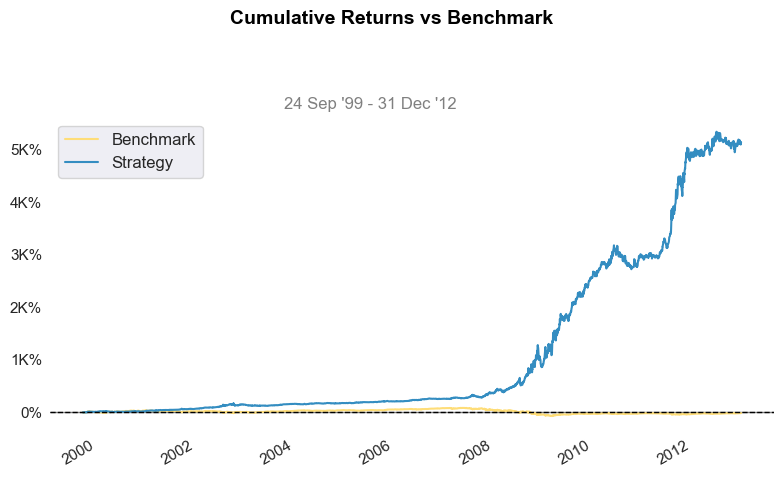

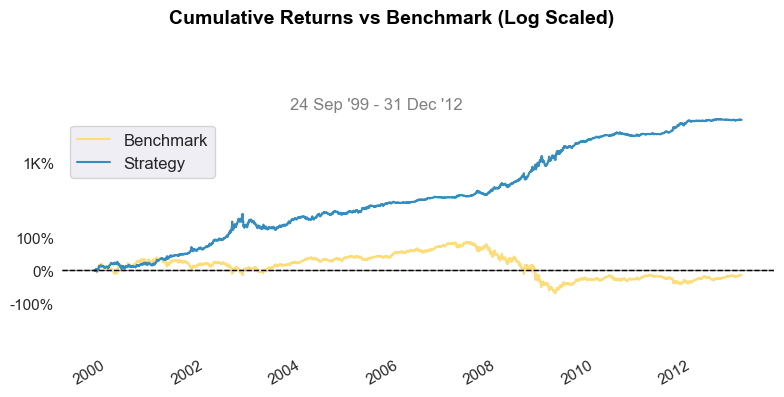

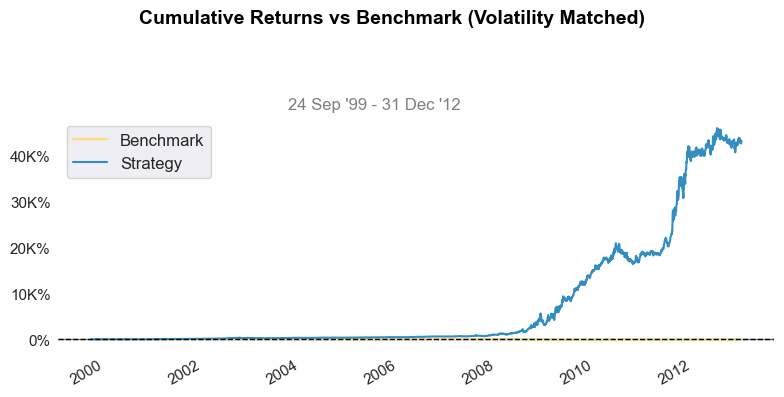

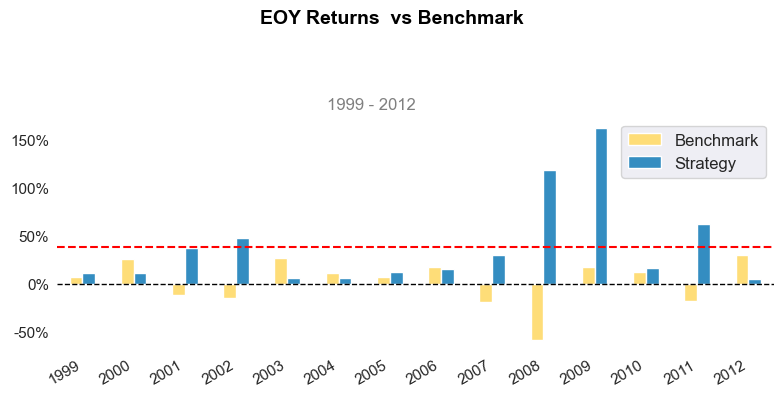

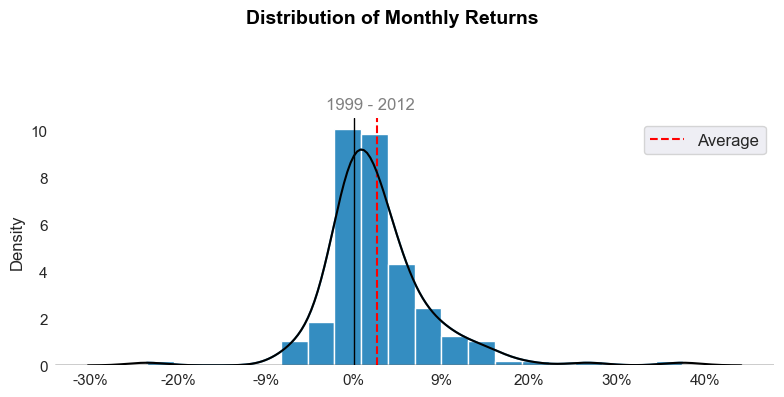

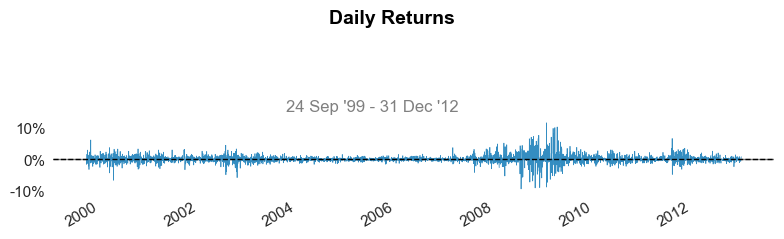

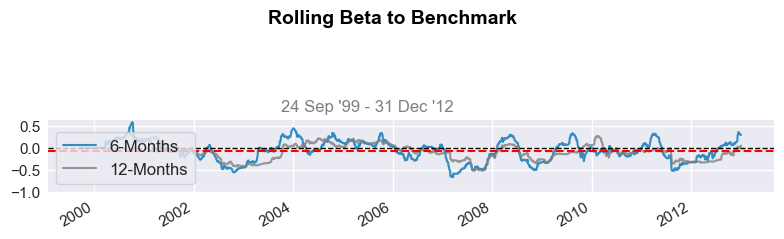

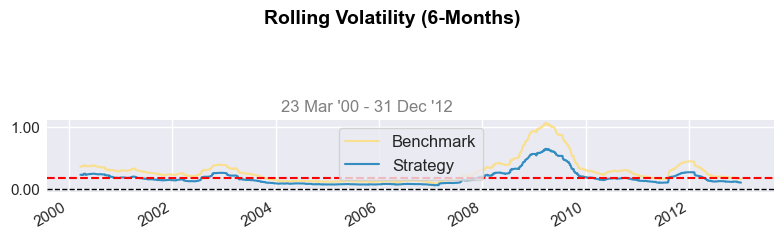

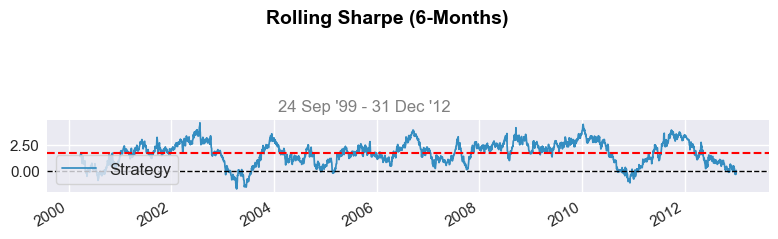

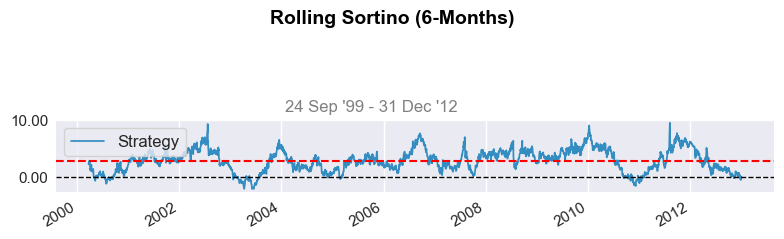

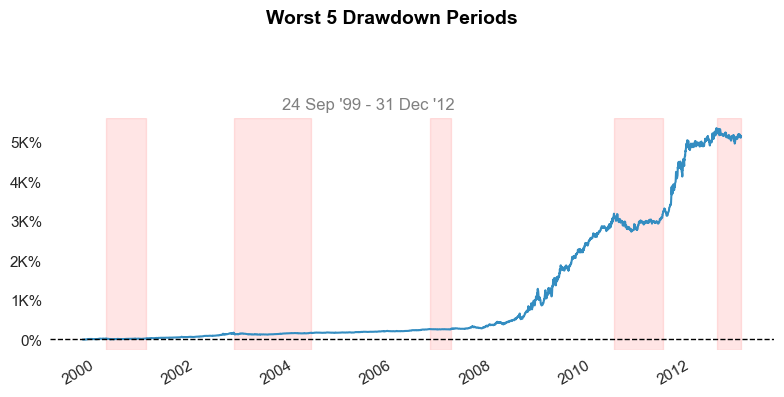

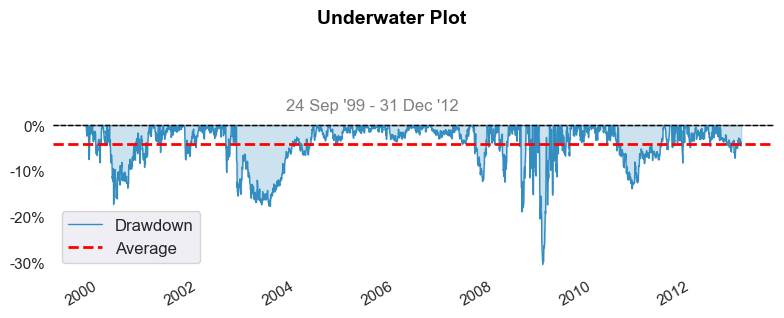

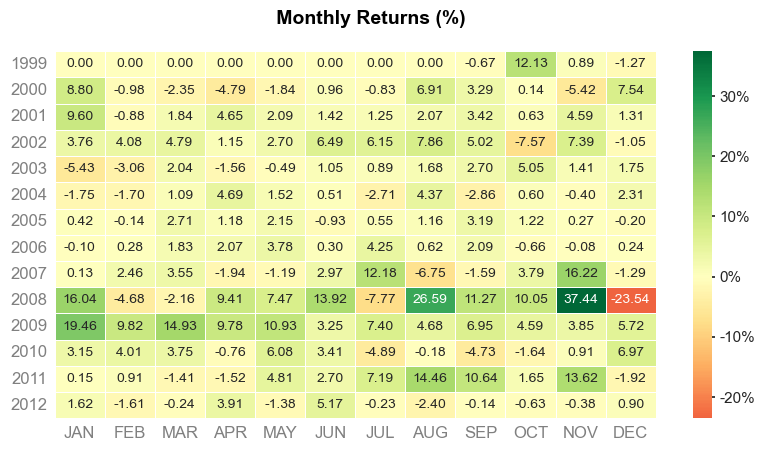

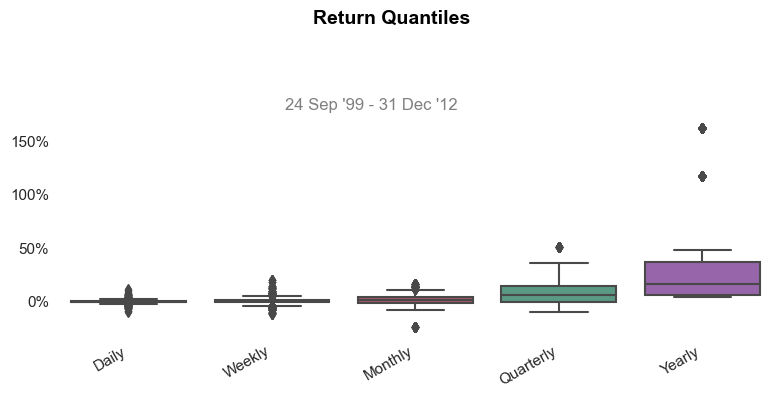

In [70]:
qs.reports.full(remove_timezone(equity_curve), remove_timezone(benchmark))

# Test model on Validation Set

In [71]:
df_validation[Y_TARGET_COL] = forward_returns.apply(np.sign)
df_validation = df_validation[df_validation[Y_TARGET_COL] != 0.0]
print(df_validation[Y_TARGET_COL].value_counts())

-1.0    443
 1.0    305
Name: fwd_8, dtype: int64


In [72]:
Xdf = (
    add_all_ta_features(
        df_validation.copy(),
        open="open",
        high="high",
        low="low",
        close="close",
        volume="volume",
    )
    .ffill()
    .dropna()
).drop(drop_cols, axis=1)

X, y = create_Xy(Xdf, selected_features, Y_TARGET_COL)
cprint(X)
cprint(y)

*******************************************************************************
dataframe information
-------------------------------------------------------------------------------
HEAD num rows: 5
                           volatility_bbh    volume_adi  trend_ema_slow  \
Date                                                                      
2013-04-16 00:00:00-04:00       12.425252  1.149546e+09       12.184894   
2013-04-17 00:00:00-04:00       12.427585  1.138058e+09       12.177503   
2013-04-18 00:00:00-04:00       12.436732  1.107105e+09       12.161220   
2013-04-19 00:00:00-04:00       12.436658  1.167998e+09       12.158563   
2013-04-22 00:00:00-04:00       12.435257  1.206511e+09       12.157096   

                           trend_kst_sig  volatility_kchi  \
Date                                                        
2013-04-16 00:00:00-04:00      18.237843              0.0   
2013-04-17 00:00:00-04:00      17.136035              0.0   
2013-04-18 00:00:00-04:00      

## run walkforward

In [73]:
scores, predictions = walkforward_with_purging_and_embargos(
    model=create_model(),
    X=X,
    y=y,
    purged_window_size=0,
    embargo_period=2,
    lookback=100,
    test_size=10,
    scaler=StandardScaler(),
    scorer=matthews_corrcoef,
)

*******************************************************
train index:: start: 2013-04-16 00:00:00-04:00 end: 2013-07-11 00:00:00-04:00
test index:: start: 2013-07-12 00:00:00-04:00 end: 2013-07-26 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 2013-04-16 00:00:00-04:00 end: 2013-07-09 00:00:00-04:00
test index:: start: 2013-07-12 00:00:00-04:00 end: 2013-07-26 00:00:00-04:00


*******************************************************
train index:: start: 2013-04-16 00:00:00-04:00 end: 2013-07-26 00:00:00-04:00
test index:: start: 2013-07-30 00:00:00-04:00 end: 2013-08-13 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 2013-04-16 00:00:00-04:00 end: 2013-07-24 00:00:00-04:00
test index:: start: 2013-07-30 00:00:00-04:00 end: 2013-08-13 00:00:00-04:00


*******************************************************
train index:: start: 2013-04-16 00:00:00-04:00 end: 2013-08-13 00:00:00-04:00
test index:: start: 2013-0

----------------------
PURGED and EMBARGOED START
train index:: start: 2013-04-16 00:00:00-04:00 end: 2014-05-14 00:00:00-04:00
test index:: start: 2014-05-19 00:00:00-04:00 end: 2014-06-03 00:00:00-04:00


*******************************************************
train index:: start: 2013-04-16 00:00:00-04:00 end: 2014-06-03 00:00:00-04:00
test index:: start: 2014-06-04 00:00:00-04:00 end: 2014-06-18 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 2013-04-16 00:00:00-04:00 end: 2014-05-30 00:00:00-04:00
test index:: start: 2014-06-04 00:00:00-04:00 end: 2014-06-18 00:00:00-04:00


*******************************************************
train index:: start: 2013-04-16 00:00:00-04:00 end: 2014-06-18 00:00:00-04:00
test index:: start: 2014-06-19 00:00:00-04:00 end: 2014-07-03 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 2013-04-16 00:00:00-04:00 end: 2014-06-16 00:00:00-04:00
test index:: start: 2014-06-19 0

----------------------
PURGED and EMBARGOED START
train index:: start: 2013-04-16 00:00:00-04:00 end: 2015-03-31 00:00:00-04:00
test index:: start: 2015-04-06 00:00:00-04:00 end: 2015-04-20 00:00:00-04:00


*******************************************************
train index:: start: 2013-04-16 00:00:00-04:00 end: 2015-04-20 00:00:00-04:00
test index:: start: 2015-04-21 00:00:00-04:00 end: 2015-05-05 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 2013-04-16 00:00:00-04:00 end: 2015-04-16 00:00:00-04:00
test index:: start: 2015-04-21 00:00:00-04:00 end: 2015-05-05 00:00:00-04:00


*******************************************************
train index:: start: 2013-04-16 00:00:00-04:00 end: 2015-05-05 00:00:00-04:00
test index:: start: 2015-05-06 00:00:00-04:00 end: 2015-05-20 00:00:00-04:00


----------------------
PURGED and EMBARGOED START
train index:: start: 2013-04-16 00:00:00-04:00 end: 2015-05-01 00:00:00-04:00
test index:: start: 2015-05-06 0

## evaluate results

In [74]:
# evaluate results
STARTING_VALUE = 100
equity_curve, equity_returns = get_estimated_backtests(
    predictions, actual_returns, starting_value=STARTING_VALUE
)
benchmark = returns_to_index(
    actual_returns.loc[equity_curve.index], starting_value=STARTING_VALUE
)

In [75]:
update_agg_results(
    hdf_store_fp,
    "validation_selected_and_tentative_features_model",
    scores,
    equity_curve,
    equity_returns,
)

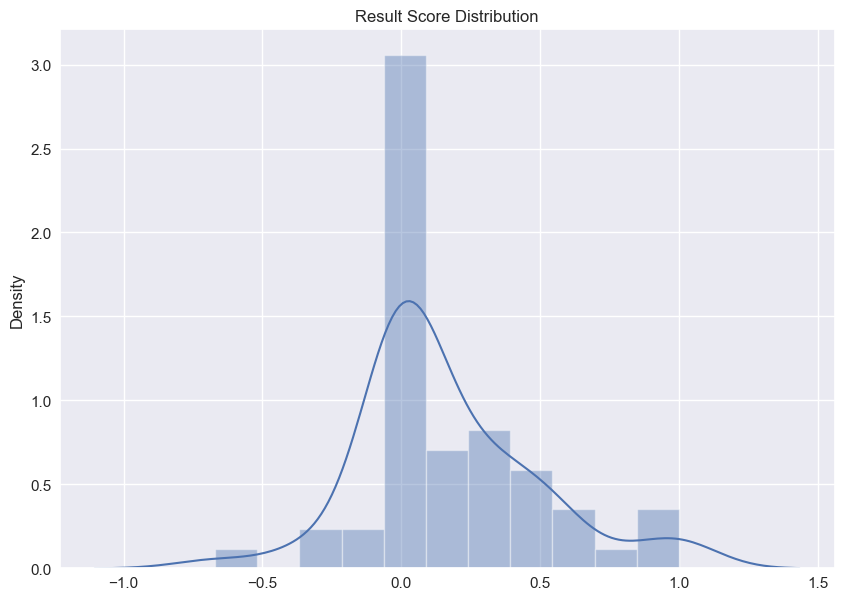

<AxesSubplot: xlabel='Date'>

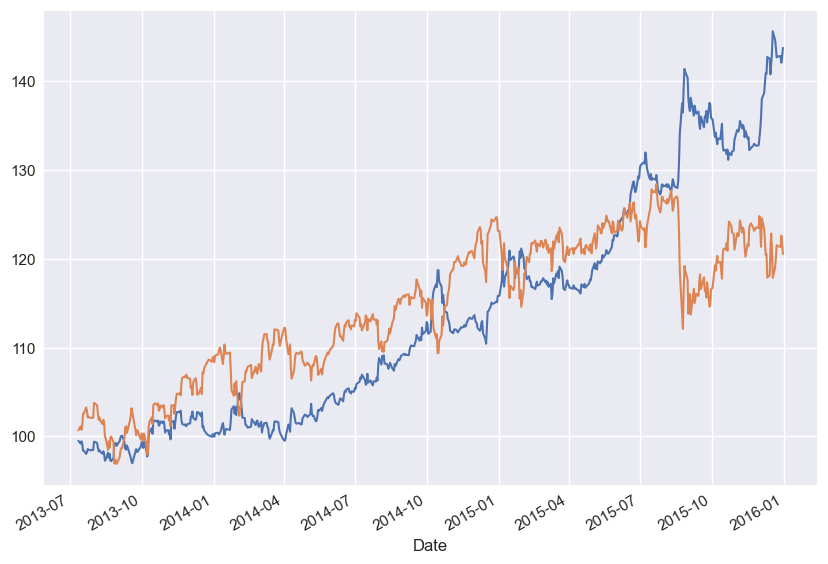

In [76]:
plot_scores(scores)
pd.Series(scores).describe()

equity_curve.plot()
benchmark.plot()

                           Strategy    Benchmark
-------------------------  ----------  -----------
Start Period               2013-07-12  2013-07-12
End Period                 2015-12-31  2015-12-31
Risk-Free Rate             0.0%        0.0%
Time in Market             98.0%       98.0%

Cumulative Return          44.48%      19.71%
CAGR﹪                     16.05%      7.55%

Sharpe                     1.6         0.57
Prob. Sharpe Ratio         99.47%      81.19%
Smart Sharpe               1.55        0.55
Sortino                    2.6         0.8
Smart Sortino              2.53        0.78
Sortino/√2                 1.84        0.57
Smart Sortino/√2           1.79        0.55
Omega                      1.31        1.31

Max Drawdown               -7.23%      -12.71%
Longest DD Days            119         161
Volatility (ann.)          9.71%       14.88%
R^2                        0.12        0.12
Information Ratio          0.02        0.02
Calmar                     2.22        0.

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2015-08-28,2015-10-22,2015-12-11,105,-7.234652,-6.867746
2,2014-10-17,2014-12-16,2015-01-06,81,-6.982126,-6.514703
3,2014-02-04,2014-04-02,2014-06-03,119,-5.112434,-5.012613
4,2015-02-02,2015-03-10,2015-05-26,113,-4.694358,-4.244238
5,2015-07-09,2015-07-27,2015-08-21,43,-3.585832,-3.365490


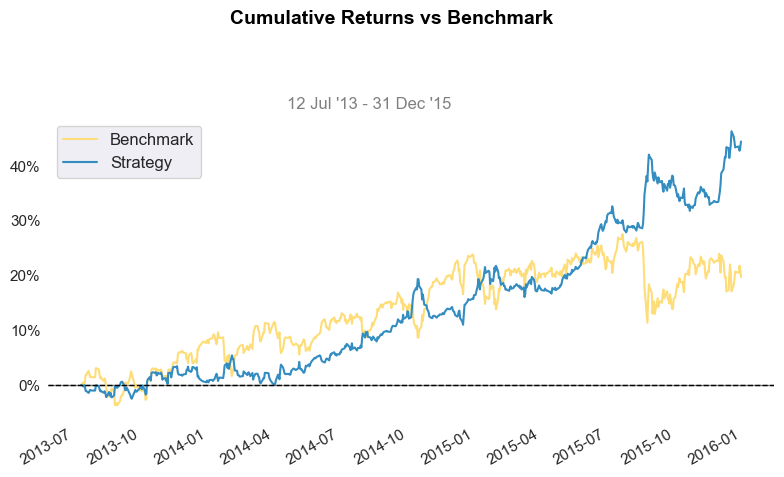

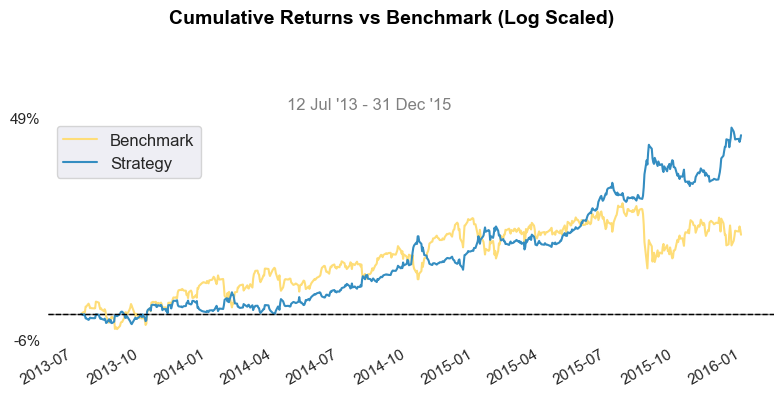

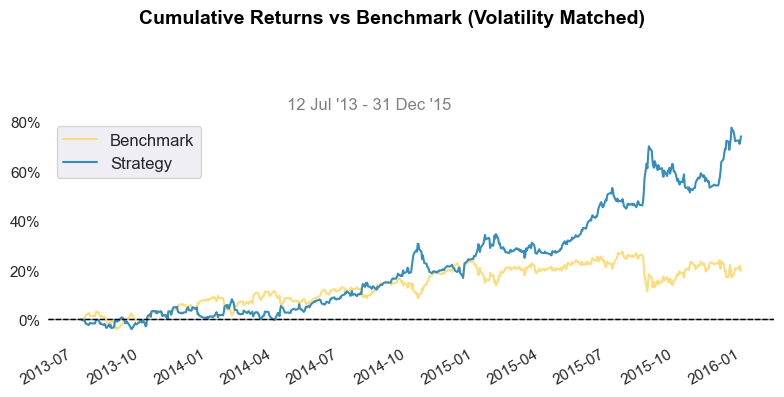

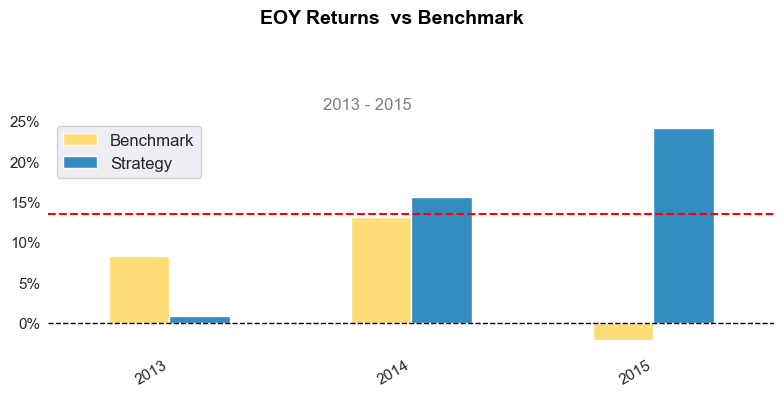

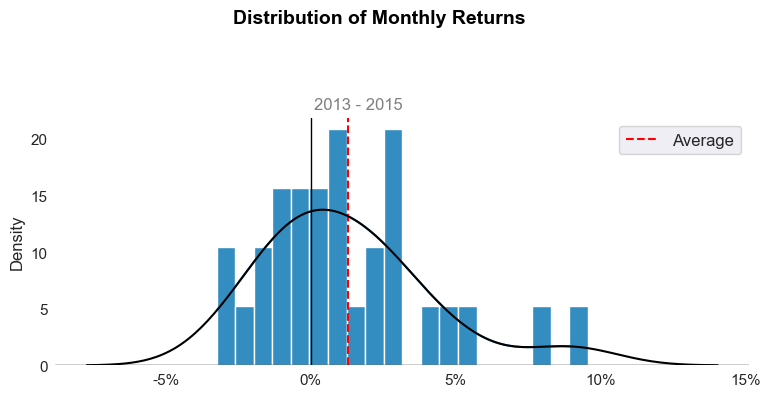

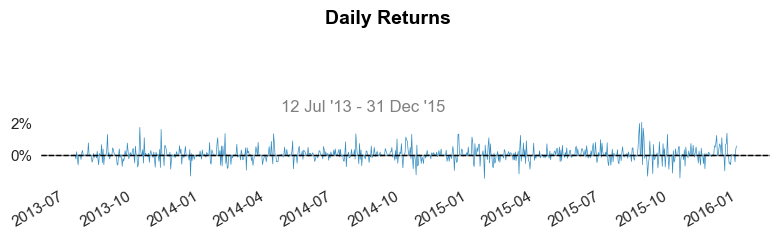

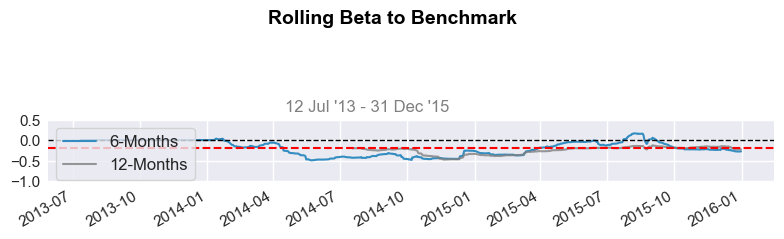

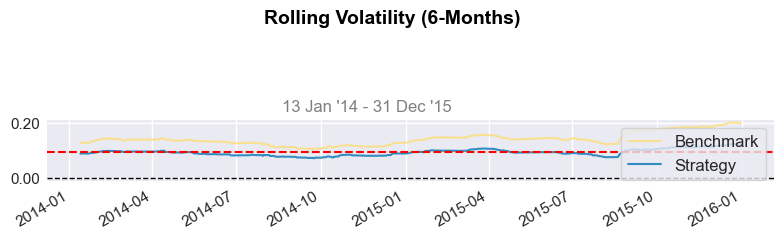

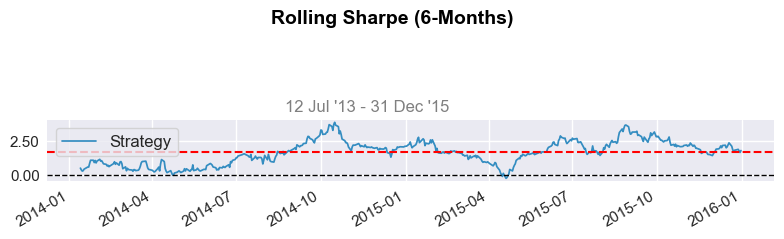

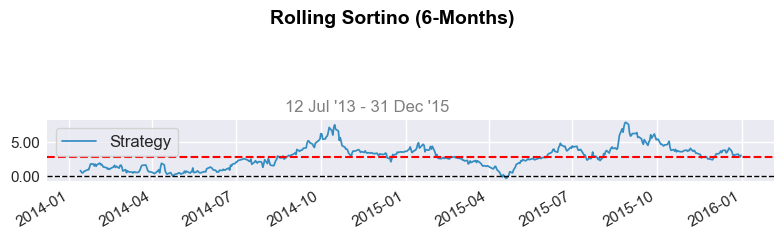

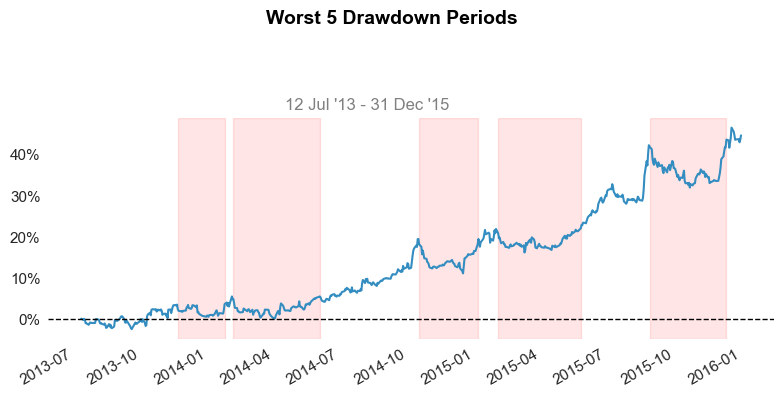

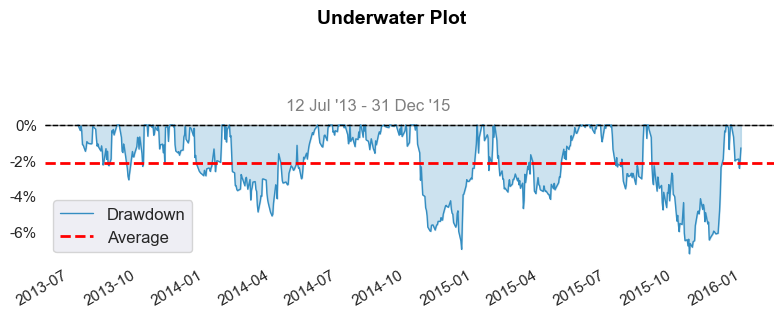

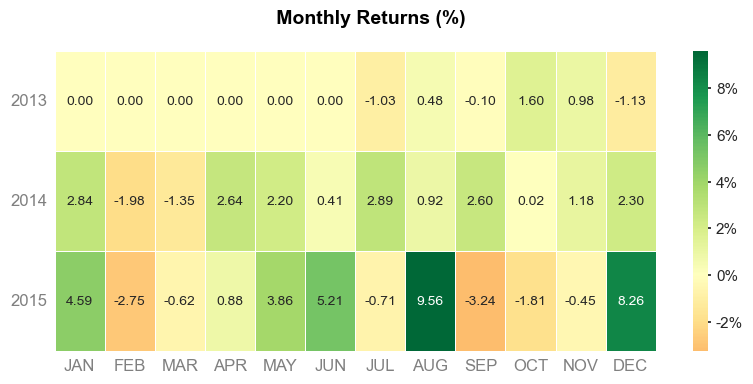

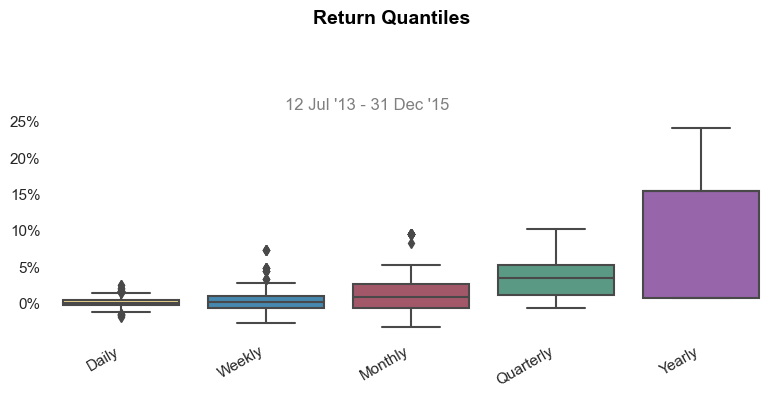

In [77]:
qs.reports.full(remove_timezone(equity_curve), remove_timezone(benchmark))